# Simulating noisy gates and quantum error correction


In [1]:
import sys
sys.path.append("src")

# standard numerics and linear algebra libraries
import numpy as np
import itertools # loop
from qutip import Bloch  
import numpy.linalg as LA
import scipy.linalg as sciLA
import matplotlib.pyplot as plt # for making plots
import time as time # measure runtimes
import scipy.sparse as sparse # sparse matrix functions
from qiskit.quantum_info import state_fidelity, Statevector, DensityMatrix
import quantum_error_corrections as qec #  # custom quantum dynamics package 

%matplotlib inline

Simulator by including the possibility of noisy (non-unitary) channels to real quantum computers. this framework to study common quantum channels and simulate quantum error correction protocols.

Single qubit channels

We start by implementing common single-qubit channels and visualizing their action on the Bloch sphere. Compared to the purely unitary case, the state of the system is now described by a density matrix $|\psi\rangle\rightarrow \rho$, and unitary operations are replaced by general quantum channels $U\rightarrow \mathcal{E}(\rho)$. Hint: For setting up the density matrix of a pure state  $\rho = |\psi\rangle \langle \psi|$ the numpy function `np.outer(psi.conj(),psi)` might be helpful.

#### (a) Defining a channel

Generate an array of Kraus operators $M_i$ for the bit flip, phase flip and amplitude damping channel.

Write a function that takes as an input (1) a density matrix of a single qubit and (2) the list of Kraus operators defining the channels and returns the density matrix after the channel has been applied.

Test your functions by applying, e.g., the bit flip channel to the states $|0\rangle$ and $|+\rangle$.

psi:
 [0.70710678+0.j 0.70710678+0.j]

rho_in:
 [[0.5+0.j 0.5+0.j]
 [0.5+0.j 0.5+0.j]]

X-axis:
 [[0.92387953+0.j         0.        -0.38268343j]
 [0.        -0.38268343j 0.92387953+0.j        ]]

Kraus operators for X-axis channel:
 [array([[0.83666003+0.j, 0.        +0.j],
       [0.        +0.j, 0.83666003+0.j]]), array([[0.50602966+0.j        , 0.        -0.20960435j],
       [0.        -0.20960435j, 0.50602966+0.j        ]])]

Density matrix after X channel:
 [[0.5-1.01719705e-18j 0.5+3.42696288e-18j]
 [0.5-1.01719705e-18j 0.5+3.42696288e-18j]]

initial Bloch vector:
 [1. 0. 0.]
Bloch vector after X channel:
 [ 1.00000000e+00 -4.44415993e-18 -5.55111512e-17]


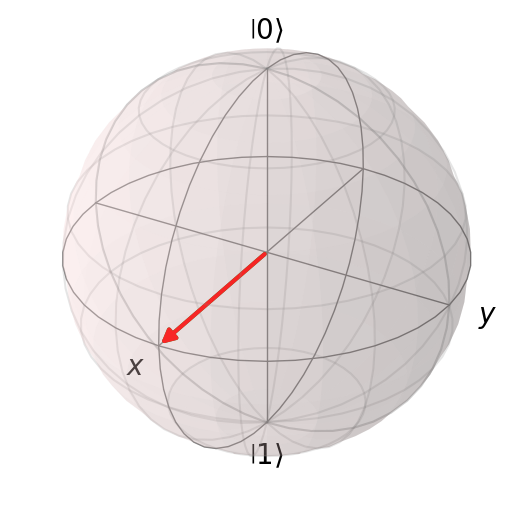

In [2]:
# Parameters
theta = np.pi / 4  
p = 0.3             
n = [1, 0, 0]    

# Initial state 
psi = qec.operators.ket_plus()  
rho_in = np.outer(psi, psi.conj())  
print("psi:\n", psi )
print()
print("rho_in:\n", rho_in)
R_x  = qec.operators.rotation_gate(theta, n)
print()
print("X-axis:\n", R_x)
print()
kraus_x = qec.operators.rotation_channel(p, R_x)
rho_x = qec.operators.apply_kraus(rho_in, kraus_x)

# Print Kraus operators and resulting state
print("Kraus operators for X-axis channel:\n", kraus_x)
print()
print("Density matrix after X channel:\n", rho_x)
print()
# Compute Bloch vectors
v_initial = qec.operators.bloch_vector(rho_in)
v_x = qec.operators.bloch_vector(rho_x)

print("initial Bloch vector:\n", v_initial)
print("Bloch vector after X channel:\n", v_x)

# Visualize on Bloch sphere
b = Bloch()
b.vector_color = ['green', 'red']  # green = original, red = after channel
b.add_vectors(v_initial)  
b.add_vectors(v_x)        
b.title = "X-axis effect on |+>"
b.show()

psi:
 [ 0.70710678+0.j -0.70710678+0.j]

rho_in:
 [[ 0.5+0.j -0.5-0.j]
 [-0.5+0.j  0.5+0.j]]

X-axis:
 [[0.92387953+0.j         0.        -0.38268343j]
 [0.        -0.38268343j 0.92387953+0.j        ]]

Kraus operators for X-axis channel:
 [array([[0.83666003+0.j, 0.        +0.j],
       [0.        +0.j, 0.83666003+0.j]]), array([[0.50602966+0.j        , 0.        -0.20960435j],
       [0.        -0.20960435j, 0.50602966+0.j        ]])]

Density matrix after X channel:
 [[ 0.5+1.01719705e-18j -0.5+3.42696288e-18j]
 [-0.5-1.01719705e-18j  0.5-3.42696288e-18j]]

initial Bloch vector:
 [-1.  0.  0.]
Bloch vector after X channel:
 [-1.00000000e+00 -4.44415993e-18 -5.55111512e-17]


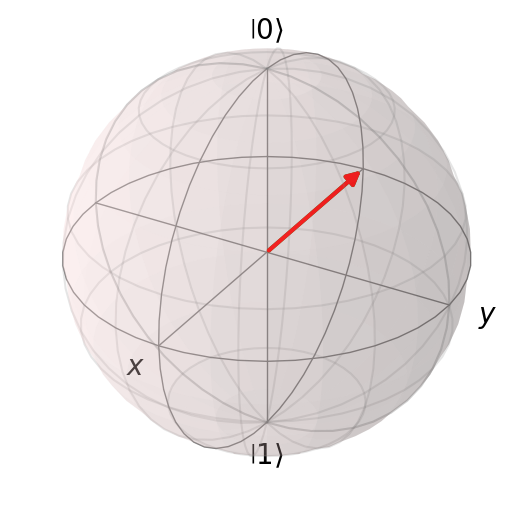

In [3]:
theta = np.pi / 4  
p = 0.3             
n = [1, 0, 0]    
psi = qec.operators.ket_minus()  
rho_in = np.outer(psi, psi.conj())  
print("psi:\n", psi )
print()
print("rho_in:\n", rho_in)
R_x  = qec.operators.rotation_gate(theta, n)
print()
print("X-axis:\n", R_x) 
print()
kraus_x = qec.operators.rotation_channel(p, R_x)
rho_x = qec.operators.apply_kraus(rho_in, kraus_x)
print("Kraus operators for X-axis channel:\n", kraus_x)
print()
print("Density matrix after X channel:\n", rho_x)
print()
v_initial = qec.operators.bloch_vector(rho_in)
v_x = qec.operators.bloch_vector(rho_x)
print("initial Bloch vector:\n", v_initial)
print("Bloch vector after X channel:\n", v_x)
b = Bloch()
b.vector_color = ['green', 'red']  
b.add_vectors(v_initial)  
b.add_vectors(v_x)        
b.title = "X-axis effect on |->"
b.show()

psi:
 [1.+0.j 0.+0.j]

rho_in:
 [[1.+0.j 0.+0.j]
 [0.+0.j 0.+0.j]]

X-axis:
 [[0.92387953+0.j         0.        -0.38268343j]
 [0.        -0.38268343j 0.92387953+0.j        ]]

Kraus operators for X-axis channel:
 [array([[0.83666003+0.j, 0.        +0.j],
       [0.        +0.j, 0.83666003+0.j]]), array([[0.50602966+0.j        , 0.        -0.20960435j],
       [0.        -0.20960435j, 0.50602966+0.j        ]])]

Density matrix after X channel:
 [[0.95606602+0.j         0.        +0.10606602j]
 [0.        -0.10606602j 0.04393398+0.j        ]]

initial Bloch vector: [0. 0. 1.]
Bloch vector after X channel: [ 0.         -0.21213203  0.91213203]


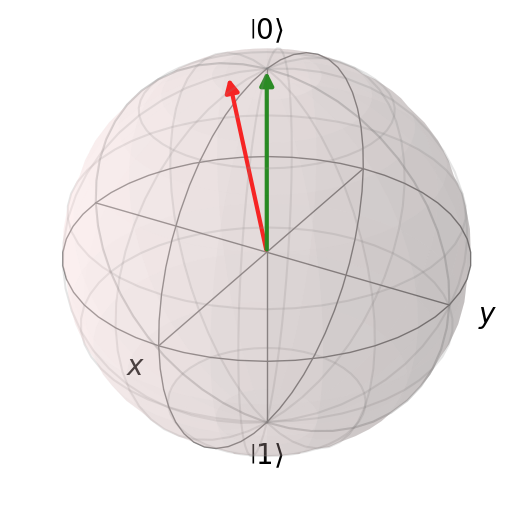

In [4]:
theta = np.pi / 4  
p = 0.3             
n = [1, 0, 0]    

psi = qec.operators.ket0()  
rho_in = np.outer(psi, psi.conj())  
print("psi:\n", psi)
print()
print("rho_in:\n", rho_in)
R_x  = qec.operators.rotation_gate(theta, n)
print()
print("X-axis:\n", R_x)
print()
kraus_x = qec.operators.rotation_channel(p, R_x)
rho_x = qec.operators.apply_kraus(rho_in, kraus_x)
print("Kraus operators for X-axis channel:\n", kraus_x)
print()
print("Density matrix after X channel:\n", rho_x)
print()
v_initial = qec.operators.bloch_vector(rho_in)
v_x = qec.operators.bloch_vector(rho_x)
print("initial Bloch vector:", v_initial)
print("Bloch vector after X channel:", v_x)
b = Bloch()
b.vector_color = ['green', 'red']  
b.add_vectors(v_initial)  
b.add_vectors(v_x)        
b.title = "X-axis effect on |0>"
b.show()

psi:
 [0.+0.j 1.+0.j]

rho_in:
 [[0.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]

X-axis:
 [[0.92387953+0.j         0.        -0.38268343j]
 [0.        -0.38268343j 0.92387953+0.j        ]]

Kraus operators for X-axis channel:
 [array([[0.31622777+0.j, 0.        +0.j],
       [0.        +0.j, 0.31622777+0.j]]), array([[0.87646908+0.j        , 0.        -0.36304538j],
       [0.        -0.36304538j, 0.87646908+0.j        ]])]

Density matrix after X channel:
 [[0.13180195+0.j         0.        -0.31819805j]
 [0.        +0.31819805j 0.86819805+0.j        ]]

initial Bloch vector: [ 0.  0. -1.]
Bloch vector after X channel: [ 0.         0.6363961 -0.7363961]


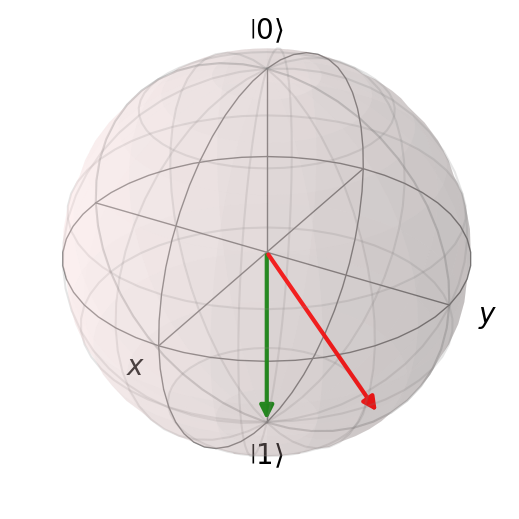

In [5]:
theta = np.pi / 4  
p = 0.9            
n = [1, 0, 0]    


psi = qec.operators.ket1()  
rho_in = np.outer(psi, psi.conj())  
print("psi:\n", psi )
print()
print("rho_in:\n", rho_in)
R_x  = qec.operators.rotation_gate(theta, n)
print()
print("X-axis:\n", R_x)
print()
kraus_x = qec.operators.rotation_channel(p, R_x)
rho_x = qec.operators.apply_kraus(rho_in, kraus_x)
print("Kraus operators for X-axis channel:\n", kraus_x)
print()
print("Density matrix after X channel:\n", rho_x)
print()
v_initial = qec.operators.bloch_vector(rho_in)
v_x = qec.operators.bloch_vector(rho_x)
print("initial Bloch vector:", v_initial)
print("Bloch vector after X channel:", v_x)
b = Bloch()
b.vector_color = ['green', 'red']  
b.add_vectors(v_initial)  
b.add_vectors(v_x)        
b.title = "X-axis effect on |1>"
b.show()

psi:
 [1.+0.j 0.+0.j]

rho_in:
 [[1.+0.j 0.+0.j]
 [0.+0.j 0.+0.j]]

Y-axis:
 [[ 0.92387953+0.j -0.38268343+0.j]
 [ 0.38268343+0.j  0.92387953+0.j]]

Kraus operators for y-axis channel:
 [array([[0.31622777+0.j, 0.        +0.j],
       [0.        +0.j, 0.31622777+0.j]]), array([[ 0.87646908+0.j, -0.36304538+0.j],
       [ 0.36304538+0.j,  0.87646908+0.j]])]

Density matrix after y channel:
 [[0.86819805+0.j 0.31819805+0.j]
 [0.31819805+0.j 0.13180195+0.j]]

initial Bloch vector: [0. 0. 1.]
Bloch vector after Y channel: [0.6363961 0.        0.7363961]


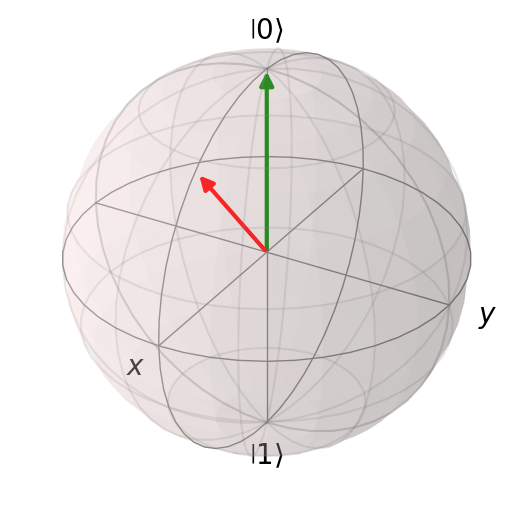

In [6]:
theta = np.pi / 4  
p = 0.9             
n = [0, 1, 0]    

psi = qec.operators.ket0()  
rho_in = np.outer(psi, psi.conj())  

print("psi:\n", psi )
print()
print("rho_in:\n", rho_in)

R_y  = qec.operators.rotation_gate(theta, n)
print()
print("Y-axis:\n", R_y)
print()
kraus_y = qec.operators.rotation_channel(p, R_y)
rho_y = qec.operators.apply_kraus(rho_in, kraus_y)
print("Kraus operators for y-axis channel:\n", kraus_y)
print()
print("Density matrix after y channel:\n", rho_y)
print()
v_initial = qec.operators.bloch_vector(rho_in)
v_y = qec.operators.bloch_vector(rho_y)
print("initial Bloch vector:", v_initial)
print("Bloch vector after Y channel:", v_y)
b = Bloch()
b.vector_color = ['green', 'red']  
b.add_vectors(v_initial)  
b.add_vectors(v_y)        
b.title = "Y-axis effect on |1>"
b.show()

psi:
 [0.+0.j 1.+0.j]

rho_in:
 [[0.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]

Y-axis:
 [[ 0.92387953+0.j -0.38268343+0.j]
 [ 0.38268343+0.j  0.92387953+0.j]]

Kraus operators for y-axis channel:
 [array([[0.31622777+0.j, 0.        +0.j],
       [0.        +0.j, 0.31622777+0.j]]), array([[ 0.87646908+0.j, -0.36304538+0.j],
       [ 0.36304538+0.j,  0.87646908+0.j]])]

Density matrix after y channel:
 [[ 0.13180195+0.j -0.31819805+0.j]
 [-0.31819805+0.j  0.86819805+0.j]]

initial Bloch vector: [ 0.  0. -1.]
Bloch vector after Y channel: [-0.6363961  0.        -0.7363961]


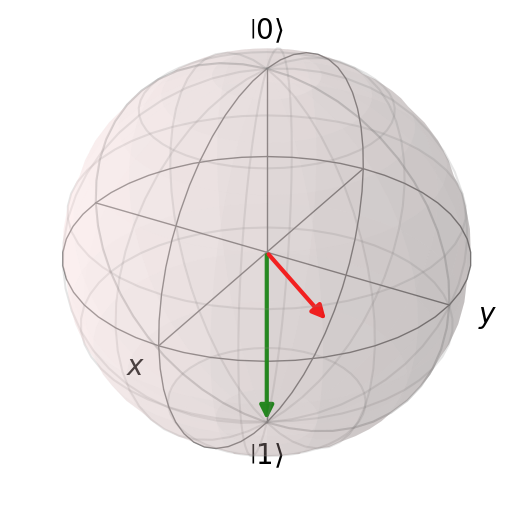

In [7]:
theta = np.pi / 4  
p = 0.9             
n = [0, 1, 0]    
psi = qec.operators.ket1()  
rho_in = np.outer(psi, psi.conj())  
print("psi:\n", psi )
print()
print("rho_in:\n", rho_in)
R_y  = qec.operators.rotation_gate(theta, n)
print()
print("Y-axis:\n", R_y)
print()
kraus_y = qec.operators.rotation_channel(p, R_y)
rho_y = qec.operators.apply_kraus(rho_in, kraus_y)
print("Kraus operators for y-axis channel:\n", kraus_y)
print()
print("Density matrix after y channel:\n", rho_y)
print()
v_initial = qec.operators.bloch_vector(rho_in)
v_y = qec.operators.bloch_vector(rho_y)
print("initial Bloch vector:", v_initial)
print("Bloch vector after Y channel:", v_y)
b = Bloch()
b.vector_color = ['green', 'red']  
b.add_vectors(v_initial)  
b.add_vectors(v_y)        
b.title = "Y-axis effect on |1>"
b.show()

psi:
 [1.+0.j 0.+0.j]

rho_in:
 [[1.+0.j 0.+0.j]
 [0.+0.j 0.+0.j]]

Y-axis:
 [[ 0.92387953+0.j -0.38268343+0.j]
 [ 0.38268343+0.j  0.92387953+0.j]]

Kraus operators for Y-axis channel:
 [array([[0.54772256+0.j, 0.        +0.j],
       [0.        +0.j, 0.54772256+0.j]]), array([[ 0.77297307+0.j, -0.32017593+0.j],
       [ 0.32017593+0.j,  0.77297307+0.j]])]

Density matrix after Y channel:
 [[0.89748737+0.j 0.24748737+0.j]
 [0.24748737+0.j 0.10251263+0.j]]

initial Bloch vector: [0. 0. 1.]
Bloch vector after Y channel: [0.49497475 0.         0.79497475]


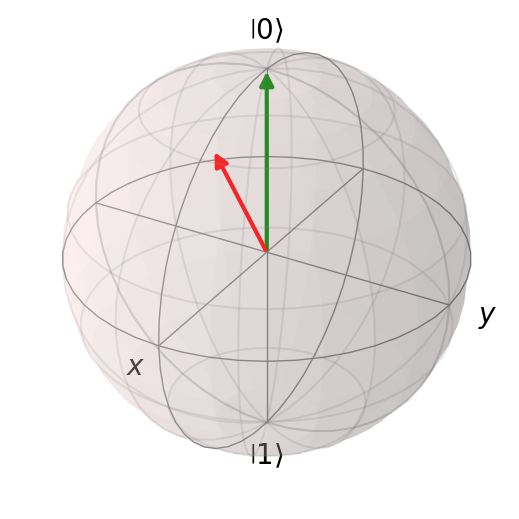

In [8]:
theta = np.pi / 4  
p = 0.7            
n = [0, 1, 0]    
psi = qec.operators.ket0()  
rho_in = np.outer(psi, psi.conj())  
print("psi:\n", psi )
print()
print("rho_in:\n", rho_in)

R_y  = qec.operators.rotation_gate(theta, n)
print()
print("Y-axis:\n", R_y)

print()
kraus_y = qec.operators.rotation_channel(p, R_y)
rho_y = qec.operators.apply_kraus(rho_in, kraus_y)


print("Kraus operators for Y-axis channel:\n", kraus_y)
print()
print("Density matrix after Y channel:\n", rho_y)
print()

v_initial = qec.operators.bloch_vector(rho_in)
v_y = qec.operators.bloch_vector(rho_y)

print("initial Bloch vector:", v_initial)
print("Bloch vector after Y channel:", v_y)

b = Bloch()
b.vector_color = ['green', 'red']  
b.add_vectors(v_initial)  
b.add_vectors(v_y)        
b.title = "Y-axis effect on |0>"
b.show()

psi:
 [ 0.70710678+0.j -0.70710678+0.j]

rho_in:
 [[ 0.5+0.j -0.5-0.j]
 [-0.5+0.j  0.5+0.j]]

Y-axis:
 [[ 0.92387953+0.j -0.38268343+0.j]
 [ 0.38268343+0.j  0.92387953+0.j]]

Kraus operators for Y-axis channel:
 [array([[0.4472136+0.j, 0.       +0.j],
       [0.       +0.j, 0.4472136+0.j]]), array([[ 0.82634298+0.j, -0.34228247+0.j],
       [ 0.34228247+0.j,  0.82634298+0.j]])]

Density matrix after Y channel:
 [[ 0.78284271+0.j -0.38284271+0.j]
 [-0.38284271+0.j  0.21715729+0.j]]

initial Bloch vector: [-1.  0.  0.]
Bloch vector after Y channel: [-0.76568542  0.          0.56568542]


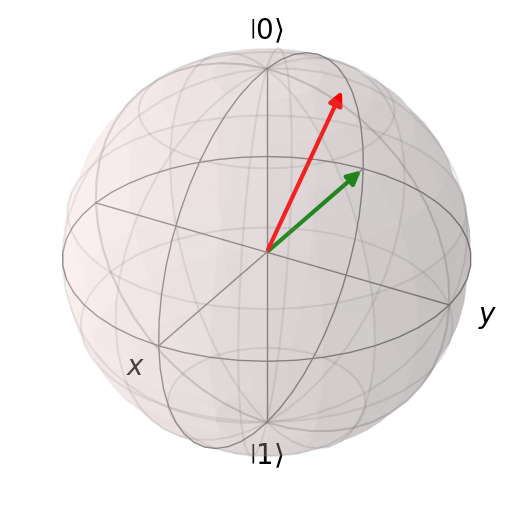

In [9]:
theta = np.pi / 4  
p = 0.8            
n = [0, 1, 0]    

psi = qec.operators.ket_minus()  
rho_in = np.outer(psi, psi.conj())  
print("psi:\n", psi )
print()
print("rho_in:\n", rho_in)
R_y  = qec.operators.rotation_gate(theta, n)
print()
print("Y-axis:\n", R_y)
print()
kraus_y = qec.operators.rotation_channel(p, R_y)
rho_y = qec.operators.apply_kraus(rho_in, kraus_y)
print("Kraus operators for Y-axis channel:\n", kraus_y)
print()
print("Density matrix after Y channel:\n", rho_y)
print()
v_initial = qec.operators.bloch_vector(rho_in)
v_y = qec.operators.bloch_vector(rho_y)
print("initial Bloch vector:", v_initial)
print("Bloch vector after Y channel:", v_y)
b = Bloch()
b.vector_color = ['green', 'red']  
b.add_vectors(v_initial)  
b.add_vectors(v_y)        
b.title = "Y-axis effect on |1>"
b.show()

psi:
 [0.70710678+0.j 0.70710678+0.j]

rho_in:
 [[0.5+0.j 0.5+0.j]
 [0.5+0.j 0.5+0.j]]

Y-axis:
 [[ 0.92387953+0.j -0.38268343+0.j]
 [ 0.38268343+0.j  0.92387953+0.j]]

Kraus operators for Y-axis channel:
 [array([[0.31622777+0.j, 0.        +0.j],
       [0.        +0.j, 0.31622777+0.j]]), array([[ 0.87646908+0.j, -0.36304538+0.j],
       [ 0.36304538+0.j,  0.87646908+0.j]])]

Density matrix after Y channel:
 [[0.18180195+0.j 0.36819805+0.j]
 [0.36819805+0.j 0.81819805+0.j]]

initial Bloch vector: [1. 0. 0.]
Bloch vector after Y channel: [ 0.7363961  0.        -0.6363961]


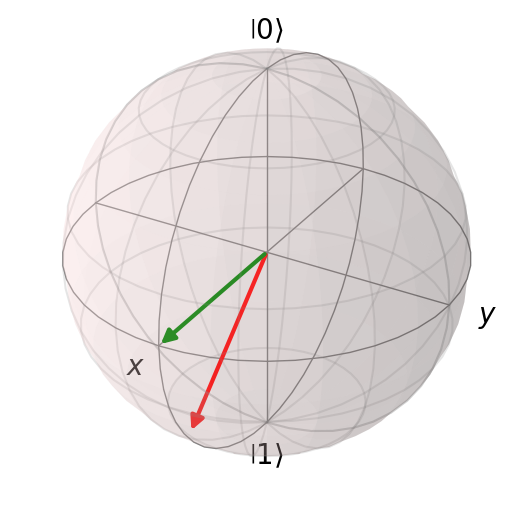

In [10]:
theta = np.pi / 4  
p = 0.9             
n = [0, 1, 0]    
psi = qec.operators.ket_plus() 
rho_in = np.outer(psi, psi.conj())  
print("psi:\n", psi )
print()
print("rho_in:\n", rho_in)
R_y  = qec.operators.rotation_gate(theta, n)
print()
print("Y-axis:\n", R_y)

print()
kraus_y = qec.operators.rotation_channel(p, R_y)
rho_y = qec.operators.apply_kraus(rho_in, kraus_y)
print("Kraus operators for Y-axis channel:\n", kraus_y)
print()
print("Density matrix after Y channel:\n", rho_y)
print()
v_initial = qec.operators.bloch_vector(rho_in)
v_y = qec.operators.bloch_vector(rho_y)
print("initial Bloch vector:", v_initial)
print("Bloch vector after Y channel:", v_y)
b = Bloch()
b.vector_color = ['green', 'red']  
b.add_vectors(v_initial)  
b.add_vectors(v_y)        
b.title = "Y-axis effect on |+>"
b.show()

psi:
 [1.+0.j 0.+0.j]

rho_in:
 [[1.+0.j 0.+0.j]
 [0.+0.j 0.+0.j]]

Z-axis:
 [[0.92387953-0.38268343j 0.        +0.j        ]
 [0.        +0.j         0.92387953+0.38268343j]]

Kraus operators for Z-axis channel:
 [array([[0.63245553+0.j, 0.        +0.j],
       [0.        +0.j, 0.63245553+0.j]]), array([[0.71563401-0.29642531j, 0.        +0.j        ],
       [0.        +0.j        , 0.71563401+0.29642531j]])]

Density matrix after Z channel:
 [[1.-4.17414242e-18j 0.+0.00000000e+00j]
 [0.+0.00000000e+00j 0.+0.00000000e+00j]]

initial Bloch vector: [0. 0. 1.]
Bloch vector after Z channel: [0. 0. 1.]


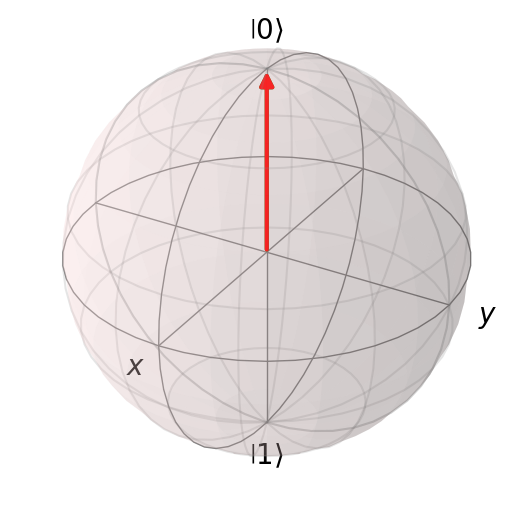

In [11]:
theta = np.pi / 4  
p = 0.6            
n = [0, 0, 1]    
psi = qec.operators.ket0() 
rho_in = np.outer(psi, psi.conj())  
print("psi:\n", psi )
print()
print("rho_in:\n", rho_in)
R_z  = qec.operators.rotation_gate(theta, n)
print()
print("Z-axis:\n", R_z)
print()
kraus_z = qec.operators.rotation_channel(p, R_z)
rho_z = qec.operators.apply_kraus(rho_in, kraus_z)
print("Kraus operators for Z-axis channel:\n", kraus_z)
print()
print("Density matrix after Z channel:\n", rho_z)
print()
v_initial = qec.operators.bloch_vector(rho_in)
v_z = qec.operators.bloch_vector(rho_z)
print("initial Bloch vector:", v_initial)
print("Bloch vector after Z channel:", v_z)
b = Bloch()
b.vector_color = ['green', 'red']  
b.add_vectors(v_initial)  
b.add_vectors(v_z)        
b.title = "Z-axis effect on |0>"
b.show()

psi:
 [0.+0.j 1.+0.j]

rho_in:
 [[0.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]

Z-axis:
 [[0.92387953-0.38268343j 0.        +0.j        ]
 [0.        +0.j         0.92387953+0.38268343j]]

Kraus operators for Z-axis channel:
 [array([[0.98994949+0.j, 0.        +0.j],
       [0.        +0.j, 0.98994949+0.j]]), array([[0.1306563-0.05411961j, 0.       +0.j        ],
       [0.       +0.j        , 0.1306563+0.05411961j]])]

Density matrix after Z channel:
 [[0.+0.00000000e+00j 0.+0.00000000e+00j]
 [0.+0.00000000e+00j 1.+2.95057639e-19j]]

initial Bloch vector: [ 0.  0. -1.]
Bloch vector after Z channel: [ 0.  0. -1.]


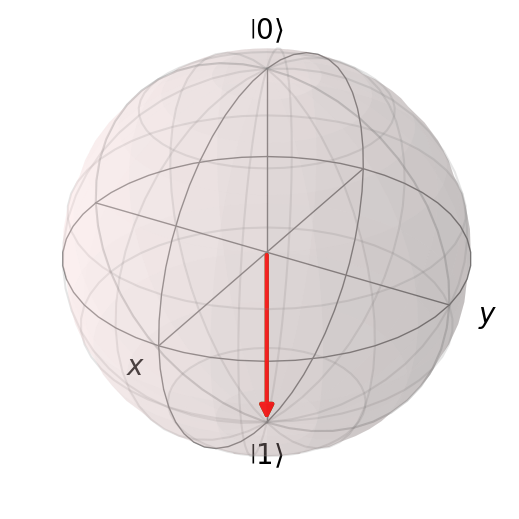

In [12]:
theta = np.pi / 4  
p = 0.02             
n = [0, 0, 1]    

psi = qec.operators.ket1() 
rho_in = np.outer(psi, psi.conj())  

print("psi:\n", psi )
print()
print("rho_in:\n", rho_in)

R_z  = qec.operators.rotation_gate(theta, n)
print()
print("Z-axis:\n", R_z)

print()
kraus_z = qec.operators.rotation_channel(p, R_z)
rho_z = qec.operators.apply_kraus(rho_in, kraus_z)

print("Kraus operators for Z-axis channel:\n", kraus_z)
print()
print("Density matrix after Z channel:\n", rho_z)
print()

v_initial = qec.operators.bloch_vector(rho_in)
v_z = qec.operators.bloch_vector(rho_z)

print("initial Bloch vector:", v_initial)
print("Bloch vector after Z channel:", v_z)

b = Bloch()
b.vector_color = ['green', 'red']  
b.add_vectors(v_initial)  
b.add_vectors(v_z)        
b.title = "Z-axis effect on |1>"
b.show()

psi:
 [0.70710678+0.j 0.70710678+0.j]

rho_in:
 [[0.5+0.j 0.5+0.j]
 [0.5+0.j 0.5+0.j]]

Z-axis:
 [[0.92387953-0.38268343j 0.        +0.j        ]
 [0.        +0.j         0.92387953+0.38268343j]]

Kraus operators for Z-axis channel:
 [array([[0.9486833+0.j, 0.       +0.j],
       [0.       +0.j, 0.9486833+0.j]]), array([[0.29215636-0.12101513j, 0.        +0.j        ],
       [0.        +0.j        , 0.29215636+0.12101513j]])]

Density matrix after Z channel:
 [[0.5       -6.12612152e-19j 0.48535534-3.53553391e-02j]
 [0.48535534+3.53553391e-02j 0.5       +6.12612152e-19j]]

initial Bloch vector: [1. 0. 0.]
Bloch vector after Z channel: [0.97071068 0.07071068 0.        ]


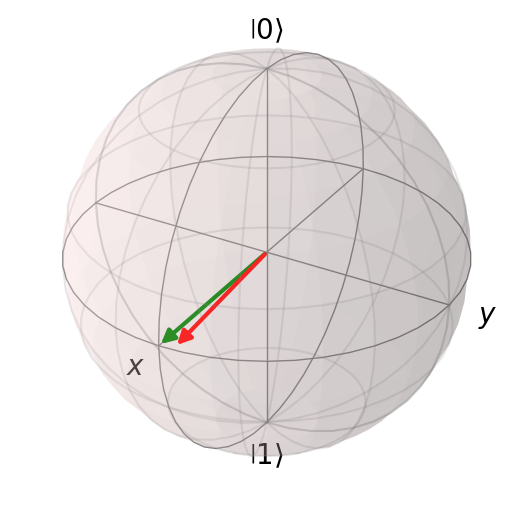

In [13]:
theta = np.pi / 4  
p = 0.1          
n = [0, 0, 1]    

psi = qec.operators.ket_plus() 
rho_in = np.outer(psi, psi.conj())  

print("psi:\n", psi )
print()
print("rho_in:\n", rho_in)

R_z  = qec.operators.rotation_gate(theta, n)
print()
print("Z-axis:\n", R_z)

print()
kraus_z = qec.operators.rotation_channel(p, R_z)
rho_z = qec.operators.apply_kraus(rho_in, kraus_z)


print("Kraus operators for Z-axis channel:\n", kraus_z)
print()
print("Density matrix after Z channel:\n", rho_z)
print()

v_initial = qec.operators.bloch_vector(rho_in)
v_z = qec.operators.bloch_vector(rho_z)

print("initial Bloch vector:", v_initial)
print("Bloch vector after Z channel:", v_z)

b = Bloch()
b.vector_color = ['green', 'red']  
b.add_vectors(v_initial)  
b.add_vectors(v_z)        
b.title = "Z-axis effect on |+>"
b.show()

psi:
 [ 0.70710678+0.j -0.70710678+0.j]

rho_in:
 [[ 0.5+0.j -0.5-0.j]
 [-0.5+0.j  0.5+0.j]]

Z-axis:
 [[0.92387953-0.38268343j 0.        +0.j        ]
 [0.        +0.j         0.92387953+0.38268343j]]

Kraus operators for Z-axis channel:
 [array([[0.31622777+0.j, 0.        +0.j],
       [0.        +0.j, 0.31622777+0.j]]), array([[0.87646908-0.36304538j, 0.        +0.j        ],
       [0.        +0.j        , 0.87646908+0.36304538j]])]

Density matrix after Z channel:
 [[ 0.5       -2.82788554e-17j -0.36819805+3.18198052e-01j]
 [-0.36819805-3.18198052e-01j  0.5       +2.82788554e-17j]]

Initial Bloch vector:
 [-1.  0.  0.]
Bloch vector after Z channel:
 [-0.7363961 -0.6363961  0.       ]


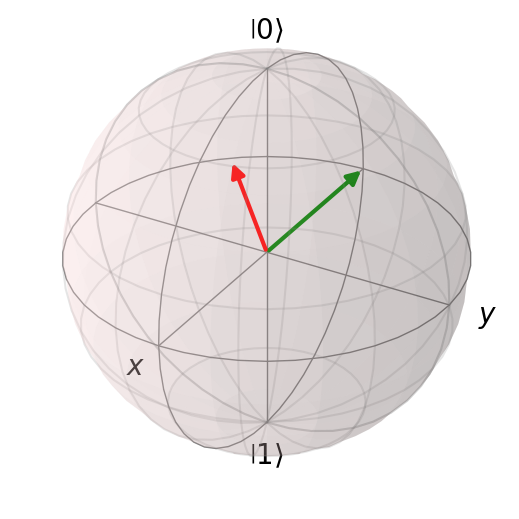

In [14]:
theta = np.pi / 4  
p = 0.9             
n = [0, 0, 1]    

psi = qec.operators.ket_minus() 
rho_in = np.outer(psi, psi.conj())  

print("psi:\n", psi )
print()
print("rho_in:\n", rho_in)

R_z  = qec.operators.rotation_gate(theta, n)
print()
print("Z-axis:\n", R_z)

print()
kraus_z = qec.operators.rotation_channel(p, R_z)
rho_z = qec.operators.apply_kraus(rho_in, kraus_z)


print("Kraus operators for Z-axis channel:\n", kraus_z)
print()
print("Density matrix after Z channel:\n", rho_z)
print()

v_initial = qec.operators.bloch_vector(rho_in)
v_z = qec.operators.bloch_vector(rho_z)

print("Initial Bloch vector:\n", v_initial)
print("Bloch vector after Z channel:\n", v_z)

b = Bloch()
b.vector_color = ['green', 'red'] 
b.add_vectors(v_initial)  
b.add_vectors(v_z)        
b.title = "Z-axis effect on |->"
b.show()

#### Defining a channel

Generate an array of Kraus operators $M_i$ for the amplitude damping channel.

Write a function that takes as an input (1) a density matrix of a single qubit and (2) the list of Kraus operators defining the channels and returns the density matrix after the channel has been applied.

Test your functions by applying, e.g., the to the states $|0\rangle$ and $|+\rangle$.

psi:
 [1.+0.j 0.+0.j]

rho_in:
 [[1.+0.j 0.+0.j]
 [0.+0.j 0.+0.j]]

Amplitude damping Kraus operators:
 [array([[1.        +0.j, 0.        +0.j],
       [0.        +0.j, 0.83666003+0.j]]), array([[0.        +0.j, 0.54772256+0.j],
       [0.        +0.j, 0.        +0.j]])]

Density matrix after amplitude damping:
 [[1.+0.j 0.+0.j]
 [0.+0.j 0.+0.j]]

initial Bloch vector:
 [0. 0. 1.]
Bloch vector after amplitude damping:
 [0. 0. 1.]


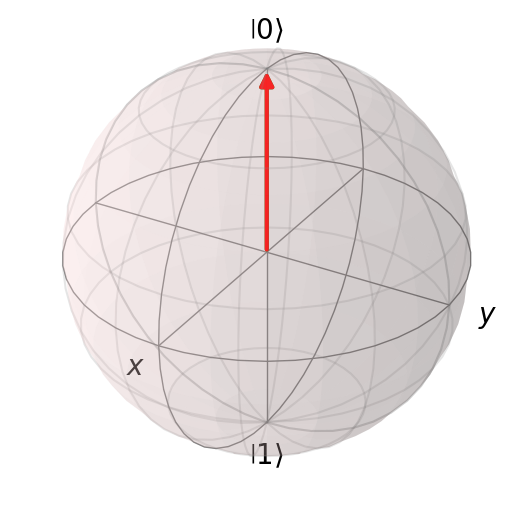

In [15]:
gamma = 0.3   
psi = qec.operators.ket0() 
rho_in = np.outer(psi, psi.conj())  
print("psi:\n", psi )
print()
print("rho_in:\n", rho_in)
kraus_amp = qec.operators.amplitude_damping_kraus(gamma)
print()
print("Amplitude damping Kraus operators:\n", kraus_amp)
rho_amp = qec.operators.apply_kraus(rho_in, kraus_amp)
print()
print("Density matrix after amplitude damping:\n", rho_amp)
print()
v_initial = qec.operators.bloch_vector(rho_in)
v_amp = qec.operators.bloch_vector(rho_amp)
print("initial Bloch vector:\n", v_initial)
print("Bloch vector after amplitude damping:\n", v_amp)

b = Bloch()
b.vector_color = ['green', 'red']  
b.add_vectors(v_initial)  
b.add_vectors(v_amp)        
b.title = "Amplitude Damping Channel effect on |1>"
b.show()

psi:
 [0.+0.j 1.+0.j]

rho_in:
 [[0.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]

Amplitude_damping_kraus:
 [array([[1.        +0.j, 0.        +0.j],
       [0.        +0.j, 0.83666003+0.j]]), array([[0.        +0.j, 0.54772256+0.j],
       [0.        +0.j, 0.        +0.j]])]
Density matrix after amplitude damping:
 [[0.3+0.j 0. +0.j]
 [0. +0.j 0.7+0.j]]
Initial Bloch vector:
 [ 0.  0. -1.]
After damping Bloch vector :
 [ 0.   0.  -0.4]


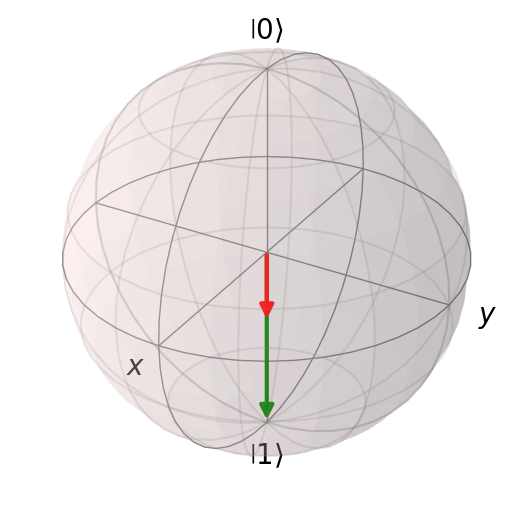

In [16]:
gamma = 0.3
psi = qec.operators.ket1()
rho_in = np.outer(psi, psi.conj())

print("psi:\n", psi )
print()
print("rho_in:\n", rho_in)

kraus_amp = qec.operators.amplitude_damping_kraus(gamma)

print()
print("Amplitude_damping_kraus:\n", kraus_amp)

rho_out = qec.operators.apply_kraus(rho_in, kraus_amp)

print("Density matrix after amplitude damping:\n", rho_out)

v_initial = qec.operators.bloch_vector(rho_in)
v_final = qec.operators.bloch_vector(rho_out)

print("Initial Bloch vector:\n", v_initial)
print("After damping Bloch vector :\n", v_final)

b = Bloch()
b.vector_color = ['green','red']
b.add_vectors(v_initial)
b.add_vectors(v_final)
b.title = "Amplitude Damping Channel"
b.show()

psi:
 [0.70710678+0.j 0.70710678+0.j]

rho_in:
 [[0.5+0.j 0.5+0.j]
 [0.5+0.j 0.5+0.j]]

Amplitude damping Kraus operators:
 [array([[1.        +0.j, 0.        +0.j],
       [0.        +0.j, 0.83666003+0.j]]), array([[0.        +0.j, 0.54772256+0.j],
       [0.        +0.j, 0.        +0.j]])]

Density matrix after amplitude damping:
 [[0.65      +0.j 0.41833001+0.j]
 [0.41833001+0.j 0.35      +0.j]]

Initial Bloch vector:
 [1. 0. 0.]
Bloch vector after amplitude damping:
 [0.83666003 0.         0.3       ]


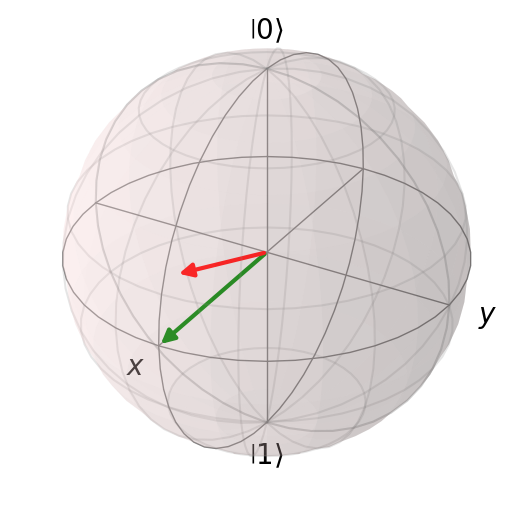

In [17]:
gamma = 0.3   
psi = qec.operators.ket_plus() 
rho_in = np.outer(psi, psi.conj())  

print("psi:\n", psi )
print()
print("rho_in:\n", rho_in)

kraus_amp = qec.operators.amplitude_damping_kraus(gamma)
print()
print("Amplitude damping Kraus operators:\n", kraus_amp)

rho_amp = qec.operators.apply_kraus(rho_in, kraus_amp)
print()
print("Density matrix after amplitude damping:\n", rho_amp)
print()

v_initial = qec.operators.bloch_vector(rho_in)
v_amp = qec.operators.bloch_vector(rho_amp)
print("Initial Bloch vector:\n", v_initial)
print("Bloch vector after amplitude damping:\n", v_amp)

b = Bloch()
b.vector_color = ['green', 'red']  
b.add_vectors(v_initial)  
b.add_vectors(v_amp)        
b.title = "Amplitude Damping Channel Effect on |1>"
b.show()

psi:
 [ 0.70710678+0.j -0.70710678+0.j]

rho_in:
 [[ 0.5+0.j -0.5-0.j]
 [-0.5+0.j  0.5+0.j]]

Amplitude_damping_kraus:
 [array([[1.        +0.j, 0.        +0.j],
       [0.        +0.j, 0.83666003+0.j]]), array([[0.        +0.j, 0.54772256+0.j],
       [0.        +0.j, 0.        +0.j]])]
Density matrix after amplitude damping:
 [[ 0.65      +0.j -0.41833001+0.j]
 [-0.41833001+0.j  0.35      +0.j]]
Initial Bloch vector:
 [-1.  0.  0.]
After damping:
 [-0.83666003  0.          0.3       ]


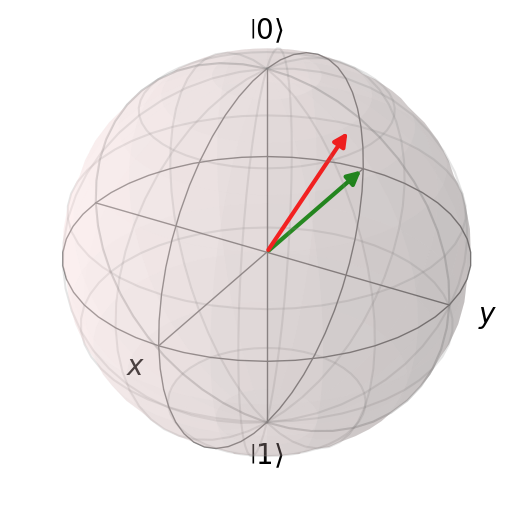

In [18]:
gamma = 0.3
psi = qec.operators.ket_minus()
rho_in = qec.operators.dm(psi)

print("psi:\n", psi )
print()
print("rho_in:\n", rho_in)

kraus_amp = qec.operators.amplitude_damping_kraus(gamma)
print()
print("Amplitude_damping_kraus:\n", kraus_amp)

rho_out = qec.operators.apply_kraus(rho_in, kraus_amp)
print("Density matrix after amplitude damping:\n", rho_out)
v_initial = qec.operators.bloch_vector(rho_in)
v_final = qec.operators.bloch_vector(rho_out)

print("Initial Bloch vector:\n", v_initial)
print("After damping:\n", v_final)

b = Bloch()
b.vector_color = ['green','red']
b.add_vectors(v_initial)
b.add_vectors(v_final)
b.title = "Amplitude Damping Channel"
b.show()

#### Defining a channel

Generate an array of Kraus operators $M_i$ for the phase damping channel.

Write a function that takes as an input (1) a density matrix of a single qubit and (2) the list of Kraus operators defining the channels and returns the density matrix after the channel has been applied.

Test your functions by applying, e.g., the to the states $|0\rangle$ and $|+\rangle$.

psi:
 [1.+0.j 0.+0.j]

rho_in:
 [[1.+0.j 0.+0.j]
 [0.+0.j 0.+0.j]]

Phase_damping_kraus:
 [array([[1.        +0.j, 0.        +0.j],
       [0.        +0.j, 0.31622777+0.j]]), array([[0.       +0.j, 0.       +0.j],
       [0.       +0.j, 0.9486833+0.j]])]

Density matrix after phase damping:
 [[1.+0.j 0.+0.j]
 [0.+0.j 0.+0.j]]

Initial Bloch vector:
 [0. 0. 1.]

After phase_damping:
 [0. 0. 1.]


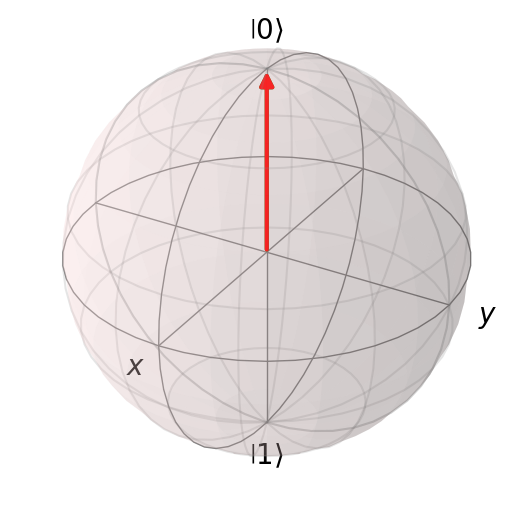

In [19]:
lmbda = 0.9
psi = qec.operators.ket0()
rho_in = qec.operators.dm(psi)

print("psi:\n", psi )
print()
print("rho_in:\n", rho_in)

kraus_phase_damping = qec.operators.phase_damping_kraus(lmbda )
print()
print("Phase_damping_kraus:\n", kraus_phase_damping)
print()
rho_out = qec.operators.apply_kraus(rho_in, kraus_phase_damping)

print("Density matrix after phase damping:\n", rho_out)
print()
v_initial = qec.operators.bloch_vector(rho_in)
v_final = qec.operators.bloch_vector(rho_out)

print("Initial Bloch vector:\n", v_initial)
print()
print("After phase_damping:\n", v_final)

b = Bloch()
b.vector_color = ['green','red']
b.add_vectors(v_initial)
b.add_vectors(v_final)
b.title = "Phase_damping Channel"
b.show()

psi:
 [0.+0.j 1.+0.j]

rho_in:
 [[0.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]

Phase_damping_kraus:
 [array([[1.        +0.j, 0.        +0.j],
       [0.        +0.j, 0.31622777+0.j]]), array([[0.       +0.j, 0.       +0.j],
       [0.       +0.j, 0.9486833+0.j]])]

Density matrix after phase damping:
 [[0.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]
Initial Bloch vector:
 [ 0.  0. -1.]
After phase_damping:
 [ 0.  0. -1.]


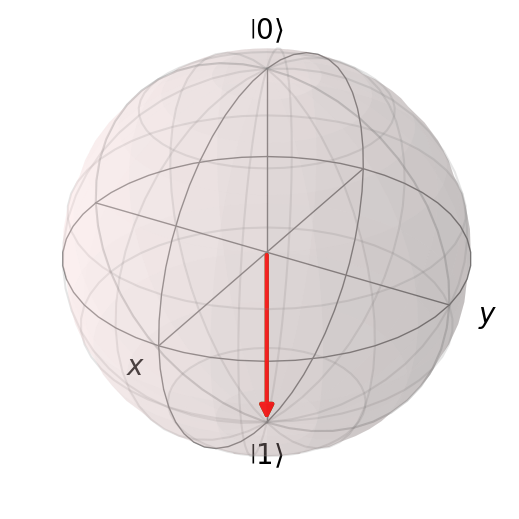

In [20]:
lmbda = 0.9
psi = qec.operators.ket1()
rho_in = qec.operators.dm(psi)
print("psi:\n", psi )
print()
print("rho_in:\n", rho_in)
kraus_phase_damping = qec.operators.phase_damping_kraus(lmbda )
print()
print("Phase_damping_kraus:\n", kraus_phase_damping)

rho_out = qec.operators.apply_kraus(rho_in, kraus_phase_damping)
print()
print("Density matrix after phase damping:\n", rho_out)

v_initial = qec.operators.bloch_vector(rho_in)
v_final = qec.operators.bloch_vector(rho_out)

print("Initial Bloch vector:\n", v_initial)
print("After phase_damping:\n", v_final)

b = Bloch()
b.vector_color = ['green','red']
b.add_vectors(v_initial)
b.add_vectors(v_final)
b.title = "Phase_damping Channel"
b.show()

psi:
 [ 0.70710678+0.j -0.70710678+0.j]

rho_in:
 [[ 0.5+0.j -0.5-0.j]
 [-0.5+0.j  0.5+0.j]]

Phase_damping_kraus:
 [array([[1.        +0.j, 0.        +0.j],
       [0.        +0.j, 0.70710678+0.j]]), array([[0.        +0.j, 0.        +0.j],
       [0.        +0.j, 0.70710678+0.j]])]

Density matrix after phase damping:
 [[ 0.5       +0.j -0.35355339+0.j]
 [-0.35355339+0.j  0.5       +0.j]]

Initial Bloch vector:
 [-1.  0.  0.]

After phase_damping:
 [-0.70710678  0.          0.        ]


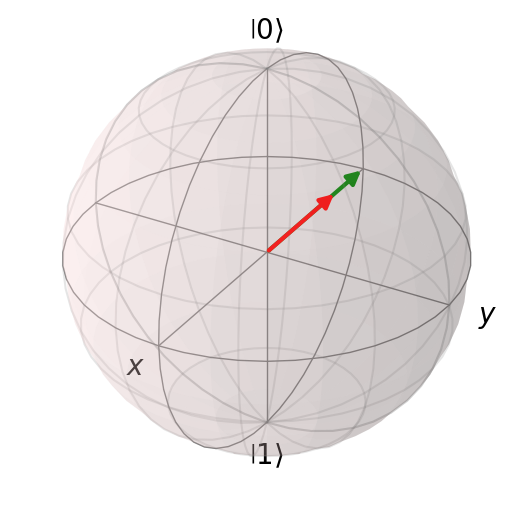

In [21]:
lmbda = 0.5
psi = qec.operators.ket_minus()
rho_in = qec.operators.dm(psi)
print("psi:\n", psi )
print()
print("rho_in:\n", rho_in)

kraus_phase_damping = qec.operators.phase_damping_kraus(lmbda )

print()
print("Phase_damping_kraus:\n", kraus_phase_damping)
rho_out = qec.operators.apply_kraus(rho_in, kraus_phase_damping)
print()
print("Density matrix after phase damping:\n", rho_out)

v_initial = qec.operators.bloch_vector(rho_in)
v_final = qec.operators.bloch_vector(rho_out)
print()
print("Initial Bloch vector:\n", v_initial)
print()
print("After phase_damping:\n", v_final)

b = Bloch()
b.vector_color = ['green','red']
b.add_vectors(v_initial)
b.add_vectors(v_final)
b.title = "Phase_damping Channel"
b.show()

psi:
 [0.70710678+0.j 0.70710678+0.j]

rho_in:
 [[0.5+0.j 0.5+0.j]
 [0.5+0.j 0.5+0.j]]

Phase_damping_kraus:
 [array([[1.        +0.j, 0.        +0.j],
       [0.        +0.j, 0.31622777+0.j]]), array([[0.       +0.j, 0.       +0.j],
       [0.       +0.j, 0.9486833+0.j]])]

Density matrix after phase damping:
 [[0.5       +0.j 0.15811388+0.j]
 [0.15811388+0.j 0.5       +0.j]]
Initial Bloch vector:
 [1. 0. 0.]

After phase_damping:
 [0.31622777 0.         0.        ]


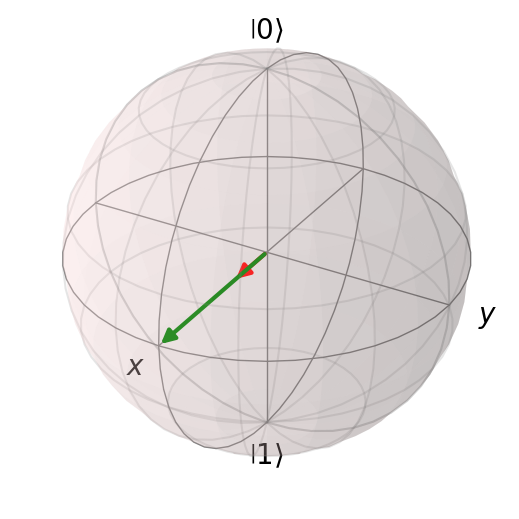

In [22]:
lmbda = 0.9
psi = qec.operators.ket_plus()
rho_in = qec.operators.dm(psi)
print("psi:\n", psi )
print()
print("rho_in:\n", rho_in)
kraus_phase_damping = qec.operators.phase_damping_kraus(lmbda )
print()
print("Phase_damping_kraus:\n", kraus_phase_damping)
rho_out = qec.operators.apply_kraus(rho_in, kraus_phase_damping)
print()
print("Density matrix after phase damping:\n", rho_out)
v_initial = qec.operators.bloch_vector(rho_in)
v_final = qec.operators.bloch_vector(rho_out)
print("Initial Bloch vector:\n", v_initial)
print()
print("After phase_damping:\n", v_final)

b = Bloch()
b.vector_color = ['green','red']
b.add_vectors(v_initial)
b.add_vectors(v_final)
b.title = "Phase_damping Channel"
b.show()

#### Defining a channel

Generate an array of Kraus operators $M_i$ for the a depolarizing channel.

Write a function that takes as an input (1) a density matrix of a single qubit and (2) the list of Kraus operators defining the channels and returns the density matrix after the channel has been applied.

Test your functions by applying, e.g., the to the states $|0\rangle$ and $|+\rangle$.

psi:
 [1.+0.j 0.+0.j]

rho_in:
 [[1.+0.j 0.+0.j]
 [0.+0.j 0.+0.j]]

Kraus operators for depolarizing channel:
 [array([[0.79056942+0.j, 0.        +0.j],
       [0.        +0.j, 0.79056942+0.j]]), array([[0.        +0.j, 0.35355339+0.j],
       [0.35355339+0.j, 0.        +0.j]]), array([[0.+0.j        , 0.-0.35355339j],
       [0.+0.35355339j, 0.+0.j        ]]), array([[ 0.35355339+0.j,  0.        +0.j],
       [ 0.        +0.j, -0.35355339+0.j]])]

Density matrix after depolarizing channel:
 [[0.75+0.j 0.  +0.j]
 [0.  +0.j 0.25+0.j]]

Initial Bloch vector:
 [0. 0. 1.]

Bloch vector after depolarizing channel:
 [0.  0.  0.5]


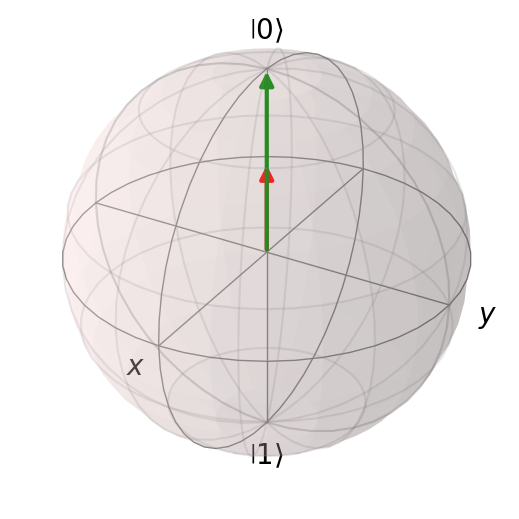

In [23]:
p = 0.5
psi = qec.operators.ket0()
rho_in = qec.operators.dm(psi)
print("psi:\n", psi )
print()
print("rho_in:\n", rho_in)
kraus_dep = qec.operators.depolarizing_kraus(p)
print()
print("Kraus operators for depolarizing channel:\n", kraus_dep)
rho_out = qec.operators.apply_kraus(rho_in, kraus_dep)
print()
print("Density matrix after depolarizing channel:\n", rho_out)
v_initial = qec.operators.bloch_vector(rho_in)
v_final = qec.operators.bloch_vector(rho_out)
print()
print("Initial Bloch vector:\n", v_initial)
print()
print("Bloch vector after depolarizing channel:\n", v_final)

b = Bloch()
b.vector_color = ['green','red']
b.add_vectors(v_initial)
b.add_vectors(v_final)
b.title = "Depolarizing Channel"
b.show()

psi:
 [0.+0.j 1.+0.j]

rho_in:
 [[0.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]

Kraus operators for depolarizing channel:
 [array([[0.83666003+0.j, 0.        +0.j],
       [0.        +0.j, 0.83666003+0.j]]), array([[0.        +0.j, 0.31622777+0.j],
       [0.31622777+0.j, 0.        +0.j]]), array([[0.+0.j        , 0.-0.31622777j],
       [0.+0.31622777j, 0.+0.j        ]]), array([[ 0.31622777+0.j,  0.        +0.j],
       [ 0.        +0.j, -0.31622777+0.j]])]

Density matrix after depolarizing channel:
 [[0.2+0.j 0. +0.j]
 [0. +0.j 0.8+0.j]]

Initial Bloch vector:
 [ 0.  0. -1.]

Bloch vector after depolarizing channel:
 [ 0.   0.  -0.6]


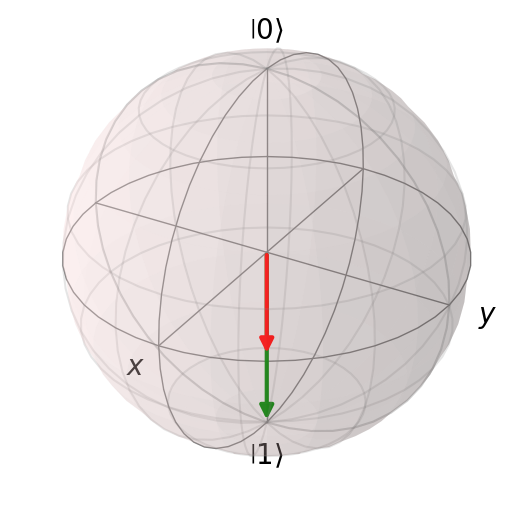

In [24]:
p = 0.4
psi = qec.operators.ket1()
rho_in = qec.operators.dm(psi)
print("psi:\n", psi )
print()
print("rho_in:\n", rho_in)
kraus_dep = qec.operators.depolarizing_kraus(p)
print()
print("Kraus operators for depolarizing channel:\n", kraus_dep)
rho_out = qec.operators.apply_kraus(rho_in, kraus_dep)
print()
print("Density matrix after depolarizing channel:\n", rho_out)
v_initial = qec.operators.bloch_vector(rho_in)
v_final = qec.operators.bloch_vector(rho_out)
print()
print("Initial Bloch vector:\n", v_initial)
print()
print("Bloch vector after depolarizing channel:\n", v_final)

b = Bloch()
b.vector_color = ['green','red']
b.add_vectors(v_initial)
b.add_vectors(v_final)
b.title = "Depolarizing Channel"
b.show()

psi:
 [ 0.70710678+0.j -0.70710678+0.j]

rho_in:
 [[ 0.5+0.j -0.5-0.j]
 [-0.5+0.j  0.5+0.j]]

Kraus operators for depolarizing channel:
 [array([[0.68920244+0.j, 0.        +0.j],
       [0.        +0.j, 0.68920244+0.j]]), array([[0.        +0.j, 0.41833001+0.j],
       [0.41833001+0.j, 0.        +0.j]]), array([[0.+0.j        , 0.-0.41833001j],
       [0.+0.41833001j, 0.+0.j        ]]), array([[ 0.41833001+0.j,  0.        +0.j],
       [ 0.        +0.j, -0.41833001+0.j]])]

Density matrix after depolarizing channel:
 [[ 0.5 +0.j -0.15+0.j]
 [-0.15+0.j  0.5 +0.j]]

Initial Bloch vector:
 [-1.  0.  0.]

Bloch vector after depolarizing channel:
 [-0.3  0.   0. ]


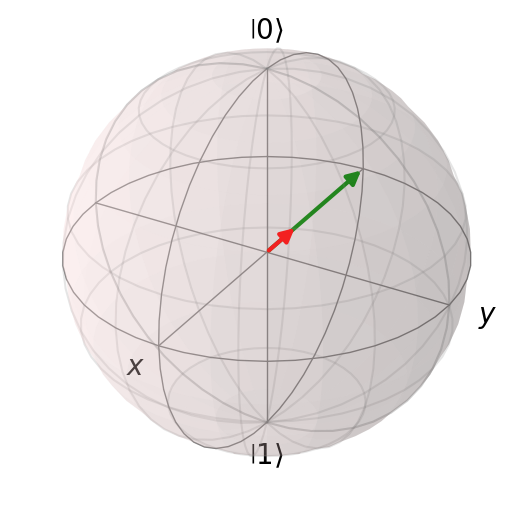

In [25]:
p = 0.7

psi = qec.operators.ket_minus()
rho_in = qec.operators.dm(psi)
print("psi:\n", psi )
print()
print("rho_in:\n", rho_in)
kraus_dep = qec.operators.depolarizing_kraus(p)
print()
print("Kraus operators for depolarizing channel:\n", kraus_dep)
rho_out = qec.operators.apply_kraus(rho_in, kraus_dep)
print()
print("Density matrix after depolarizing channel:\n", rho_out)
v_initial = qec.operators.bloch_vector(rho_in)
v_final = qec.operators.bloch_vector(rho_out)
print()
print("Initial Bloch vector:\n", v_initial)
print()
print("Bloch vector after depolarizing channel:\n", v_final)

b = Bloch()
b.vector_color = ['green','red']
b.add_vectors(v_initial)
b.add_vectors(v_final)
b.title = "Depolarizing Channel"
b.show()

psi:
 [0.70710678+0.j 0.70710678+0.j]

rho_in:
 [[0.5+0.j 0.5+0.j]
 [0.5+0.j 0.5+0.j]]

Kraus operators for depolarizing channel:
 [array([[0.79056942+0.j, 0.        +0.j],
       [0.        +0.j, 0.79056942+0.j]]), array([[0.        +0.j, 0.35355339+0.j],
       [0.35355339+0.j, 0.        +0.j]]), array([[0.+0.j        , 0.-0.35355339j],
       [0.+0.35355339j, 0.+0.j        ]]), array([[ 0.35355339+0.j,  0.        +0.j],
       [ 0.        +0.j, -0.35355339+0.j]])]

Density matrix after depolarizing channel:
 [[0.5 +0.j 0.25+0.j]
 [0.25+0.j 0.5 +0.j]]

Initial Bloch vector: [1. 0. 0.]

Bloch vector after depolarizing channel: [0.5 0.  0. ]


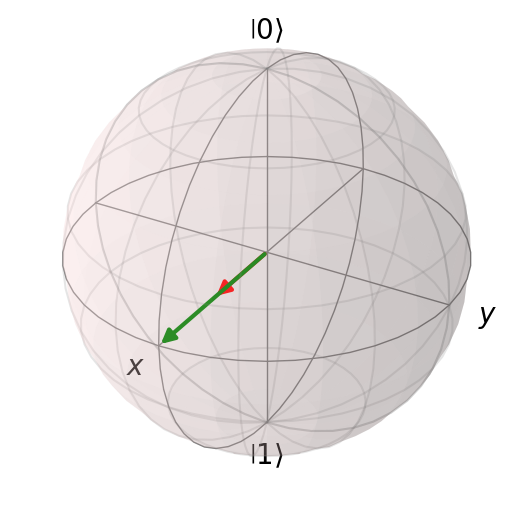

In [26]:
p = 0.5
psi = qec.operators.ket_plus()
rho_in = qec.operators.dm(psi)
print("psi:\n", psi )
print()
print("rho_in:\n", rho_in)
kraus_dep = qec.operators.depolarizing_kraus(p)
print()
print("Kraus operators for depolarizing channel:\n", kraus_dep)
rho_out = qec.operators.apply_kraus(rho_in, kraus_dep)
print()
print("Density matrix after depolarizing channel:\n", rho_out)
v_initial = qec.operators.bloch_vector(rho_in)
v_final = qec.operators.bloch_vector(rho_out)
print()
print("Initial Bloch vector:", v_initial)
print()
print("Bloch vector after depolarizing channel:", v_final)

b = Bloch()
b.vector_color = ['green','red']
b.add_vectors(v_initial)
b.add_vectors(v_final)
b.title = "Depolarizing Channel"
b.show()

#### (b) Visualization on the Bloch sphere

Write a function that calculates the Bloch vector $\overrightarrow{r}=(r_X,r_Y,r_Z)$. the Bloch vector for a pure state (so that formalism won't necessarily work here). For mixed states, one can calculate the Bloch vector element via the equation 
$$r_J = \mathrm{Tr}(\rho J),$$ 
where $J$ is either $X,Y,Z$ and $\mathrm{Tr}$ represents the trace of a matrix (see `np.trace`).

First, take a pure state (say, for example, $|\psi\rangle = |1\rangle$). Apply (separately) each of the three channels we defined earlier to this state. Plot the original state on the Bloch sphere, as well as the three states after applying the channels (i.e., one state with the phase flip, the other with the bit flip, the other with the amplitude damping). Play around with the parameters to see how the channels alter the state.

Second, sample some homogeneously distributed points on the surface of the Bloch sphere by generating random pure states. An easy way to do this is to sample 2-dimensional vectors of complex numbers with random Gaussian distributed real and imaginary parts. Don't forget to normalise your state after generating the random values!

Tip for random state generation: generate the real and complex part of state separately. You may find the function `np.random.normal(mu,sigma,dim)` to be useful here.

Apply the channels defined above (e.g., with $p=0.3$) to each of these random pure states. Calculate the resulting Bloch vectors and plot them (with the original Bloch vectors) on the Bloch sphere to see the "flow" in the Bloch sphere that each channel induces.

Quantum Noise Channels on the Bloch Sphere
Green vectors = original states
Red vectors = states after the noise channel
States used: |0> and |+>


Bit Flip on |0>:
 [[0.5+0.j 0. +0.j]
 [0. +0.j 0.5+0.j]]
Bit Flip on |+>:
 [[0.5+0.j 0.5+0.j]
 [0.5+0.j 0.5+0.j]]
Phase Flip on |0>:
 [[1.+0.j 0.+0.j]
 [0.+0.j 0.+0.j]]
Phase Flip on |+>:
 [[0.5+0.j 0. +0.j]
 [0. +0.j 0.5+0.j]]
Amplitude Damping on |0>:
 [[1.+0.j 0.+0.j]
 [0.+0.j 0.+0.j]]
Amplitude Damping on |+>:
 [[0.75      +0.j 0.35355339+0.j]
 [0.35355339+0.j 0.25      +0.j]]

Bit Flip Bloch vector|0>:
 [0. 0. 0.]
Bit Flip Bloch vector|+>:
 [1. 0. 0.]
Phase Flip Bloch vector|0>:
 [0. 0. 1.]
Phase Flip Bloch vector|+>:
 [0. 0. 0.]
Amplitude Damping Bloch vector|0>:
 [0. 0. 1.]
Amplitude Damping Bloch vector|+>:
 [0.70710678 0.         0.5       ]
Bloch Sphere: Bit Flip Channel


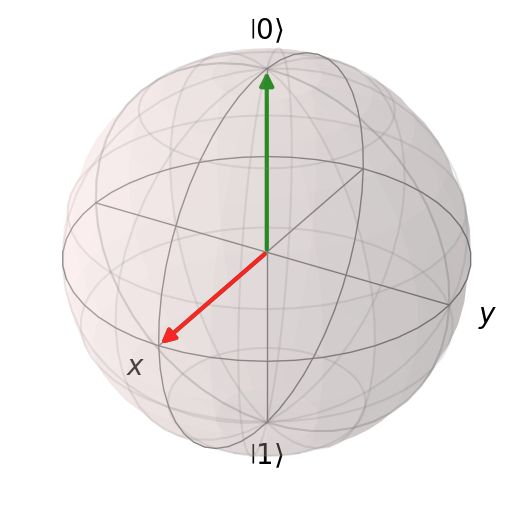

Bloch Sphere: Phase Flip Channel


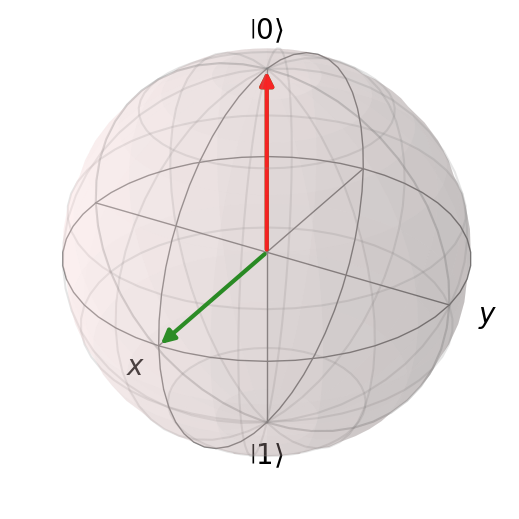

Bloch Sphere Amplitude Damping Channel


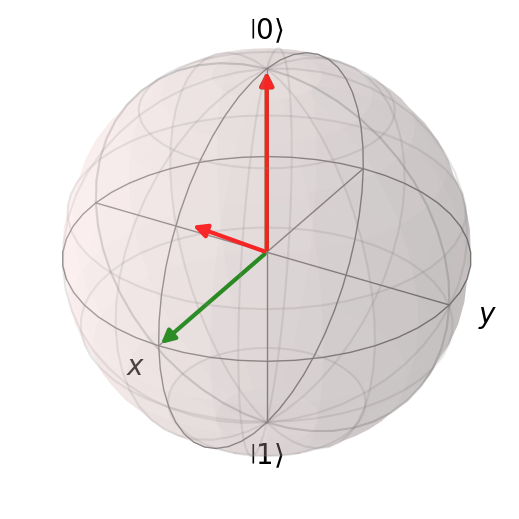

In [27]:
print("Quantum Noise Channels on the Bloch Sphere")
print("Green vectors = original states")
print("Red vectors = states after the noise channel")
print("States used: |0> and |+>")
print()

# Set channel probability
p = 0.5
bitflip_ops = qec.operators.bit_flip_kraus(p)
phaseflip_ops = qec.operators.phase_flip_kraus(p)
ampdamp_ops = qec.operators.amplitude_damping_kraus(p)

# Define states
psi0 = qec.operators.ket0()
psi_plus = qec.operators.ket_plus()
# Convert to density matrices
rho0 = qec.operators.dm(psi0)
rho_plus = qec.operators.dm(psi_plus)

# Apply channels
rho0_bitflip = qec.operators.apply_channel(rho0, bitflip_ops)
rho_plus_bitflip = qec.operators.apply_channel(rho_plus, bitflip_ops)

rho0_phaseflip = qec.operators.apply_channel(rho0, phaseflip_ops)
rho_plus_phaseflip = qec.operators.apply_channel(rho_plus, phaseflip_ops)

rho0_ampdamp = qec.operators.apply_channel(rho0, ampdamp_ops)
rho_plus_ampdamp = qec.operators.apply_channel(rho_plus, ampdamp_ops)

# Print density matrices
print()
print("Bit Flip on |0>:\n", rho0_bitflip)
print("Bit Flip on |+>:\n", rho_plus_bitflip)

print("Phase Flip on |0>:\n", rho0_phaseflip)
print("Phase Flip on |+>:\n", rho_plus_phaseflip)

print("Amplitude Damping on |0>:\n", rho0_ampdamp)
print("Amplitude Damping on |+>:\n", rho_plus_ampdamp)

print()
print("Bit Flip Bloch vector|0>:\n", qec.operators.bloch_vector(rho0_bitflip))
print("Bit Flip Bloch vector|+>:\n", qec.operators.bloch_vector(rho_plus_bitflip))

print("Phase Flip Bloch vector|0>:\n", qec.operators.bloch_vector(rho0_phaseflip))
print("Phase Flip Bloch vector|+>:\n", qec.operators.bloch_vector(rho_plus_phaseflip))

print("Amplitude Damping Bloch vector|0>:\n", qec.operators.bloch_vector(rho0_ampdamp))
print("Amplitude Damping Bloch vector|+>:\n", qec.operators.bloch_vector(rho_plus_ampdamp))
print("Bloch Sphere: Bit Flip Channel")

b1 = Bloch()
b1.vector_color = ['green','green','red','red']
b1.add_vectors(qec.operators.bloch_vector(rho0))
b1.add_vectors(qec.operators.bloch_vector(rho_plus))
b1.add_vectors(qec.operators.bloch_vector(rho0_bitflip))
b1.add_vectors(qec.operators.bloch_vector(rho_plus_bitflip))
b1.title = "Bit flip channel effect"
b1.show()
print("Bloch Sphere: Phase Flip Channel")

b2 = Bloch()
b2.vector_color = ['green','green','red','red']
b2.add_vectors(qec.operators.bloch_vector(rho0))
b2.add_vectors(qec.operators.bloch_vector(rho_plus))
b2.add_vectors(qec.operators.bloch_vector(rho0_phaseflip))
b2.add_vectors(qec.operators.bloch_vector(rho_plus_phaseflip))
b2.title = "Phase flip channel effect"
b2.show()


print("Bloch Sphere Amplitude Damping Channel")
b3 = Bloch()
b3.vector_color = ['green','green','red','red']
b3.add_vectors(qec.operators.bloch_vector(rho0))
b3.add_vectors(qec.operators.bloch_vector(rho_plus))
b3.add_vectors(qec.operators.bloch_vector(rho0_ampdamp))
b3.add_vectors(qec.operators.bloch_vector(rho_plus_ampdamp))
b3.title = "Amplitude Damping Channel Effect"
b3.show()

### Bloch Sphere Visualization of Quantum Noise Channels

We study how Bit Flip, Phase Flip, and Amplitude Damping channels affect the qubit states |0⟩ and |+⟩. Green arrows represent the original states, and red arrows represent the states after the noise channel.

 Channels on a register

we will now consider single qubit channels which act on qubits that are part of a register. 

#### (a) Single qubit channels in an n-bit register

Build Kraus operators for a given channel that act on qubit $i$ within a register of $n$ qubits. The unitary single qubit gates considered on Problem Set 2 are a subclass of these.

Hints: Recall that that if we want to apply a single qubit gate in this formalism, we can do so in the same way we apply the Kraus operators, e.g., if we want to apply a Hadamard gate, the channel would be 
$$\mathcal{E}(\rho) = H\rho H^\dagger.$$

Build your single quubit channel acting on the n-qubit register by creating a list of single qubit gates acting on the n-qubit register. That is, create the single qubit Kraus operators acting on the n-qubit register, then use these to create the channel.

Test your function on a few states where we already know the result, e.g., apply the Hadamard *channel* to the $|0\rangle$ state. 

In [28]:
n = 3
target = 2 
psi = qec.operators.ket0()
for _ in range(n-1):
    psi = np.kron(psi, qec.operators.ket0()) 
psi = qec.operators.normalize_state(psi)
rho_in = np.outer(psi, psi.conj())
kraus_single = [qec.operators.H]
kraus_full = qec.operators.single_qubit_channel_n_register(kraus_single, n, target)
rho_out = qec.operators.apply_kraus(rho_in, kraus_full)
print("Initial n-qubit state :\n", rho_in)
print()
print("Kraus operator for Hadamard channel on qubit :\n", kraus_full)
print()
print("Density matrix after Hadamard channel:\n", rho_out)

Initial n-qubit state :
 [[1.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]]

Kraus operator for Hadamard channel on qubit :
 [array([[ 0.70710678+0.j,  0.70710678+0.j,  0.        +0.j,
         0.        +0.j,  0.        +0.j,  0.        +0.j,
         0.        +0.j,  0.        +0.j],
       [ 0.70710678+0.j, -0.70710678+0.j,  0.        +0.j,
        -0.        +0.j,  0.        +0.j, -0.        +0.j,
         0.        +0.j, -0.        +0.j],
       [ 0.        +0.j,  0.        +0.j,  0.70710678+0.j,
         0.70710678+0.j,  0.        +0.j,  0.        +0.j,
         0. 

n-bit register¶ function on a few states where we already know the result, e.g., apply the  depolarizing channel to the $|0\rangle$ state. for n=4

In [29]:
p = 0.2
n = 4
psi = qec.operators.ket0
initial_state = np.kron(np.kron(psi(), psi()), np.kron(psi(), psi()))
print("initial_state :\n", initial_state) 
print()
rho_in = np.outer(initial_state, initial_state.conj())
kraus_dep = qec.operators.depolarizing_kraus_nqubits(p, n)
rho_out = qec.operators.apply_kraus(rho_in, kraus_dep)
print("Density matrix:\n", rho_in)
print()
print("Density matrix after depolarizing channel:\n", rho_out)

initial_state :
 [1.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j
 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]

Density matrix:
 [[1.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j
  0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j
  0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j
  0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j
  0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j
  0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j
  0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j
  0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0

n-bit register¶ function on a few states where we already know the result, e.g., apply the  depolarizing channel to the $|0\rangle$ state. for n=4 

In [30]:
p = 0.2
n = 4
psi = qec.operators.ket_plus
initial_state = np.kron(np.kron(psi(), psi()), np.kron(psi(), psi()))
print("initial_state :\n", initial_state) 
print()
rho_in = np.outer(initial_state, initial_state.conj())
kraus_dep = qec.operators.depolarizing_kraus_nqubits(p, n)
rho_out = qec.operators.apply_kraus(rho_in, kraus_dep)
print("Density matrix:\n", rho_in)
print()
print("Density matrix after depolarizing channel:\n", rho_out)

initial_state :
 [0.25+0.j 0.25+0.j 0.25+0.j 0.25+0.j 0.25+0.j 0.25+0.j 0.25+0.j 0.25+0.j
 0.25+0.j 0.25+0.j 0.25+0.j 0.25+0.j 0.25+0.j 0.25+0.j 0.25+0.j 0.25+0.j]

Density matrix:
 [[0.0625+0.j 0.0625+0.j 0.0625+0.j 0.0625+0.j 0.0625+0.j 0.0625+0.j
  0.0625+0.j 0.0625+0.j 0.0625+0.j 0.0625+0.j 0.0625+0.j 0.0625+0.j
  0.0625+0.j 0.0625+0.j 0.0625+0.j 0.0625+0.j]
 [0.0625+0.j 0.0625+0.j 0.0625+0.j 0.0625+0.j 0.0625+0.j 0.0625+0.j
  0.0625+0.j 0.0625+0.j 0.0625+0.j 0.0625+0.j 0.0625+0.j 0.0625+0.j
  0.0625+0.j 0.0625+0.j 0.0625+0.j 0.0625+0.j]
 [0.0625+0.j 0.0625+0.j 0.0625+0.j 0.0625+0.j 0.0625+0.j 0.0625+0.j
  0.0625+0.j 0.0625+0.j 0.0625+0.j 0.0625+0.j 0.0625+0.j 0.0625+0.j
  0.0625+0.j 0.0625+0.j 0.0625+0.j 0.0625+0.j]
 [0.0625+0.j 0.0625+0.j 0.0625+0.j 0.0625+0.j 0.0625+0.j 0.0625+0.j
  0.0625+0.j 0.0625+0.j 0.0625+0.j 0.0625+0.j 0.0625+0.j 0.0625+0.j
  0.0625+0.j 0.0625+0.j 0.0625+0.j 0.0625+0.j]
 [0.0625+0.j 0.0625+0.j 0.0625+0.j 0.0625+0.j 0.0625+0.j 0.0625+0.j
  0.0625+0.j 0.062

Test your function on a few states where we already know the result, e.g., apply the Hadamar*channel* to the $|+\rangle$ state. 

In [31]:
n = 3
target = 2 
psi = qec.operators.ket_plus()
for _ in range(n-1):
    psi = np.kron(psi, qec.operators.ket_plus()) 
psi = qec.operators.normalize_state(psi)
rho_in = np.outer(psi, psi.conj())
kraus_single = [qec.operators.H]
kraus_full = qec.operators.single_qubit_channel_n_register(kraus_single, n, target)
rho_out = qec.operators.apply_kraus(rho_in, kraus_full)
print("Initial n-qubit state :\n", rho_in)
print()
print("Kraus operator for Hadamard channel on qubit :\n", kraus_full)
print()
print("Density matrix after Hadamard channel:\n", rho_out)

Initial n-qubit state :
 [[0.125+0.j 0.125+0.j 0.125+0.j 0.125+0.j 0.125+0.j 0.125+0.j 0.125+0.j
  0.125+0.j]
 [0.125+0.j 0.125+0.j 0.125+0.j 0.125+0.j 0.125+0.j 0.125+0.j 0.125+0.j
  0.125+0.j]
 [0.125+0.j 0.125+0.j 0.125+0.j 0.125+0.j 0.125+0.j 0.125+0.j 0.125+0.j
  0.125+0.j]
 [0.125+0.j 0.125+0.j 0.125+0.j 0.125+0.j 0.125+0.j 0.125+0.j 0.125+0.j
  0.125+0.j]
 [0.125+0.j 0.125+0.j 0.125+0.j 0.125+0.j 0.125+0.j 0.125+0.j 0.125+0.j
  0.125+0.j]
 [0.125+0.j 0.125+0.j 0.125+0.j 0.125+0.j 0.125+0.j 0.125+0.j 0.125+0.j
  0.125+0.j]
 [0.125+0.j 0.125+0.j 0.125+0.j 0.125+0.j 0.125+0.j 0.125+0.j 0.125+0.j
  0.125+0.j]
 [0.125+0.j 0.125+0.j 0.125+0.j 0.125+0.j 0.125+0.j 0.125+0.j 0.125+0.j
  0.125+0.j]]

Kraus operator for Hadamard channel on qubit :
 [array([[ 0.70710678+0.j,  0.70710678+0.j,  0.        +0.j,
         0.        +0.j,  0.        +0.j,  0.        +0.j,
         0.        +0.j,  0.        +0.j],
       [ 0.70710678+0.j, -0.70710678+0.j,  0.        +0.j,
        -0.        +0.j,

Test your function on a few states where we already know the result, e.g., apply the Hadamar*channel* to the $|+\rangle$ state. X

In [33]:
n = 3
target = 2 
psi = qec.operators.ket_plus()
for _ in range(n-1):
    psi = np.kron(psi, qec.operators.ket_plus()) 
psi = qec.operators.normalize_state(psi)
rho_in = np.outer(psi, psi.conj())
kraus_single = [qec.operators.X]
kraus_full = qec.operators.single_qubit_channel_n_register(kraus_single, n, target)
rho_out = qec.operators.apply_kraus(rho_in, kraus_full)
print("Initial n-qubit state :\n", rho_in)
print()
print("Kraus operator for X channel on qubit :\n", kraus_full)
print()
print("Density matrix after X channel:\n", rho_out)

Initial n-qubit state :
 [[0.125+0.j 0.125+0.j 0.125+0.j 0.125+0.j 0.125+0.j 0.125+0.j 0.125+0.j
  0.125+0.j]
 [0.125+0.j 0.125+0.j 0.125+0.j 0.125+0.j 0.125+0.j 0.125+0.j 0.125+0.j
  0.125+0.j]
 [0.125+0.j 0.125+0.j 0.125+0.j 0.125+0.j 0.125+0.j 0.125+0.j 0.125+0.j
  0.125+0.j]
 [0.125+0.j 0.125+0.j 0.125+0.j 0.125+0.j 0.125+0.j 0.125+0.j 0.125+0.j
  0.125+0.j]
 [0.125+0.j 0.125+0.j 0.125+0.j 0.125+0.j 0.125+0.j 0.125+0.j 0.125+0.j
  0.125+0.j]
 [0.125+0.j 0.125+0.j 0.125+0.j 0.125+0.j 0.125+0.j 0.125+0.j 0.125+0.j
  0.125+0.j]
 [0.125+0.j 0.125+0.j 0.125+0.j 0.125+0.j 0.125+0.j 0.125+0.j 0.125+0.j
  0.125+0.j]
 [0.125+0.j 0.125+0.j 0.125+0.j 0.125+0.j 0.125+0.j 0.125+0.j 0.125+0.j
  0.125+0.j]]

Kraus operator for X channel on qubit :
 [array([[0.+0.j, 1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
       [1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
       [0.+0.j, 0.+0.j, 0.+0.j, 1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
       [0.+0.j, 0.+0.j, 1.+0.j, 

Test your function on a few states where we already know the result, e.g., apply the Hadamar*channel* to the $|+\rangle$ state. y

In [34]:
n = 3
target = 2 
psi = qec.operators.ket_plus()
for _ in range(n-1):
    psi = np.kron(psi, qec.operators.ket_plus()) 
psi = qec.operators.normalize_state(psi)
rho_in = np.outer(psi, psi.conj())
kraus_single = [qec.operators.Y]
kraus_full = qec.operators.single_qubit_channel_n_register(kraus_single, n, target)
rho_out = qec.operators.apply_kraus(rho_in, kraus_full)
print("Initial n-qubit state :\n", rho_in)
print()
print("Kraus operator for Y channel on qubit :\n", kraus_full)
print()
print("Density matrix after Y channel:\n", rho_out)

Initial n-qubit state :
 [[0.125+0.j 0.125+0.j 0.125+0.j 0.125+0.j 0.125+0.j 0.125+0.j 0.125+0.j
  0.125+0.j]
 [0.125+0.j 0.125+0.j 0.125+0.j 0.125+0.j 0.125+0.j 0.125+0.j 0.125+0.j
  0.125+0.j]
 [0.125+0.j 0.125+0.j 0.125+0.j 0.125+0.j 0.125+0.j 0.125+0.j 0.125+0.j
  0.125+0.j]
 [0.125+0.j 0.125+0.j 0.125+0.j 0.125+0.j 0.125+0.j 0.125+0.j 0.125+0.j
  0.125+0.j]
 [0.125+0.j 0.125+0.j 0.125+0.j 0.125+0.j 0.125+0.j 0.125+0.j 0.125+0.j
  0.125+0.j]
 [0.125+0.j 0.125+0.j 0.125+0.j 0.125+0.j 0.125+0.j 0.125+0.j 0.125+0.j
  0.125+0.j]
 [0.125+0.j 0.125+0.j 0.125+0.j 0.125+0.j 0.125+0.j 0.125+0.j 0.125+0.j
  0.125+0.j]
 [0.125+0.j 0.125+0.j 0.125+0.j 0.125+0.j 0.125+0.j 0.125+0.j 0.125+0.j
  0.125+0.j]]

Kraus operator for Y channel on qubit :
 [array([[0.+0.j, 0.-1.j, 0.+0.j, 0.-0.j, 0.+0.j, 0.-0.j, 0.+0.j, 0.-0.j],
       [0.+1.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
       [0.+0.j, 0.-0.j, 0.+0.j, 0.-1.j, 0.+0.j, 0.-0.j, 0.+0.j, 0.-0.j],
       [0.+0.j, 0.+0.j, 0.+1.j, 

Test your function on a few states where we already know the result, e.g., apply the Hadamar*channel* to the $|+\rangle$ state. y


In [35]:
n = 3
target = 2 
psi = qec.operators.ket_plus()
for _ in range(n-1):
    psi = np.kron(psi, qec.operators.ket_plus()) 
psi = qec.operators.normalize_state(psi)
rho_in = np.outer(psi, psi.conj())
kraus_single = [qec.operators.Z]
kraus_full = qec.operators.single_qubit_channel_n_register(kraus_single, n, target)
rho_out = qec.operators.apply_kraus(rho_in, kraus_full)
print("Initial n-qubit state :\n", rho_in)
print()
print("Kraus operator for Y channel on qubit :\n", kraus_full)
print()
print("Density matrix after Y channel:\n", rho_out)

Initial n-qubit state :
 [[0.125+0.j 0.125+0.j 0.125+0.j 0.125+0.j 0.125+0.j 0.125+0.j 0.125+0.j
  0.125+0.j]
 [0.125+0.j 0.125+0.j 0.125+0.j 0.125+0.j 0.125+0.j 0.125+0.j 0.125+0.j
  0.125+0.j]
 [0.125+0.j 0.125+0.j 0.125+0.j 0.125+0.j 0.125+0.j 0.125+0.j 0.125+0.j
  0.125+0.j]
 [0.125+0.j 0.125+0.j 0.125+0.j 0.125+0.j 0.125+0.j 0.125+0.j 0.125+0.j
  0.125+0.j]
 [0.125+0.j 0.125+0.j 0.125+0.j 0.125+0.j 0.125+0.j 0.125+0.j 0.125+0.j
  0.125+0.j]
 [0.125+0.j 0.125+0.j 0.125+0.j 0.125+0.j 0.125+0.j 0.125+0.j 0.125+0.j
  0.125+0.j]
 [0.125+0.j 0.125+0.j 0.125+0.j 0.125+0.j 0.125+0.j 0.125+0.j 0.125+0.j
  0.125+0.j]
 [0.125+0.j 0.125+0.j 0.125+0.j 0.125+0.j 0.125+0.j 0.125+0.j 0.125+0.j
  0.125+0.j]]

Kraus operator for Y channel on qubit :
 [array([[ 1.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,
         0.+0.j],
       [ 0.+0.j, -1.+0.j,  0.+0.j, -0.+0.j,  0.+0.j, -0.+0.j,  0.+0.j,
        -0.+0.j],
       [ 0.+0.j,  0.+0.j,  1.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,
  

#### (b) Noisy Bell state preparation

Now apply this formalism to simulate a noisy Bell state preparation (i.e., two qubits). After applying the Hadamard and CNOT gates to the register (to create the Bell state), apply bit flip channels to both qubits.

After this, calculate the fidelity with the perfect Bell state. The fidelity of the state is given by $$F=\sqrt{|\langle\psi|\rho|\psi\rangle|},$$
where $|\psi\rangle$ is the (pure) target state (in our case, the perfect Bell state).

Plot the fidelity as a function of $p$ to observe how the noisy Bell state preparation changes for varying the probability of having a bit flip.

Hints: 
1) Write a function that takes $p$ as an input and returns the fidelity.

2) Prepare your perfect Bell state using unitary gates.

In [37]:
initial_state = np.kron(qec.operators.ket0(), qec.operators.ket0())
H1 = np.kron(qec.operators.H, qec.operators.I)
state_after_H = H1 @ initial_state
CNOT12 = qec.operators.controlled_gate(qec.operators.X, 0, 1, 2)
psi_bell = CNOT12 @ state_after_H

print("Bell state:\n", psi_bell)

Bell state:
 [0.70710678+0.j 0.        +0.j 0.        +0.j 0.70710678+0.j]


In [39]:
initial_state = np.kron(qec.operators.ket0(), qec.operators.ket0())
H1 = np.kron(qec.operators.H, qec.operators.I)
state_after_H = H1 @ initial_state
CNOT12 = qec.operators.controlled_gate(qec.operators.X, 0, 1, 2)
psi_bell = CNOT12 @ state_after_H
print("psi_bell:\n", psi_bell)
print()

rho_bell = qec.operators.dm(psi_bell)
kraus_2q = qec.operators.bit_flip_kraus_nqubits(p=p, n=2)
kraus_3q = qec.operators.bit_flip_kraus_nqubits(p=p, n=3) 

kraus_2q = qec.operators.bit_flip_kraus_nqubits(p=0.9, n=2)
rho_noisy = qec.operators.apply_kraus(rho_bell, kraus_2q)

# Fidelity
F2 = np.sqrt(np.abs(np.vdot(psi_bell, rho_noisy @ psi_bell)))
print("Fidelity after 2-qubit bit-flip:\n:", F2)
print()

psi_3q = np.kron(qec.operators.ket0(), np.kron(qec.operators.ket0(), qec.operators.ket0())) 
rho_3q = qec.operators.dm(psi_3q)

kraus_3q = qec.operators.bit_flip_kraus_nqubits(p=0.1, n=3)
rho_noisy_3q = qec.operators.apply_kraus(rho_3q, kraus_3q)


psi_ghz = (np.kron(np.kron(qec.operators.ket0(), qec.operators.ket0()), qec.operators.ket0()) +
           np.kron(np.kron(qec.operators.ket1(), qec.operators.ket1()), qec.operators.ket1())) / np.sqrt(2)
rho_ghz = qec.operators.dm(psi_ghz)

print("psi_ghz:\n", psi_ghz)
print()
print("rho_ghz:\n", rho_ghz)

kraus_3q = qec.operators.bit_flip_kraus_nqubits(p=0.1, n=3)
rho_noisy = qec.operators.apply_kraus(rho_ghz, kraus_3q)
F3 = np.sqrt(np.abs(np.vdot(psi_ghz, rho_noisy @ psi_ghz))) 
print("Fidelity after 3-qubit bit-flip:\n:", F3)
print()

psi_bell:
 [0.70710678+0.j 0.        +0.j 0.        +0.j 0.70710678+0.j]

Fidelity after 2-qubit bit-flip:
: 0.9055385138137416

psi_ghz:
 [0.70710678+0.j 0.        +0.j 0.        +0.j 0.        +0.j
 0.        +0.j 0.        +0.j 0.        +0.j 0.70710678+0.j]

rho_ghz:
 [[0.5+0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0.5+0.j]
 [0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j]
 [0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j]
 [0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j]
 [0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j]
 [0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j]
 [0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j]
 [0.5+0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0.5+0.j]]
Fidelity after 3-qubit bit-flip:
: 0.854400374531753



Plot the fidelity as a function of $p$ to observe how the noisy Bell state preparation changes for varying the probability of having a bit flip.

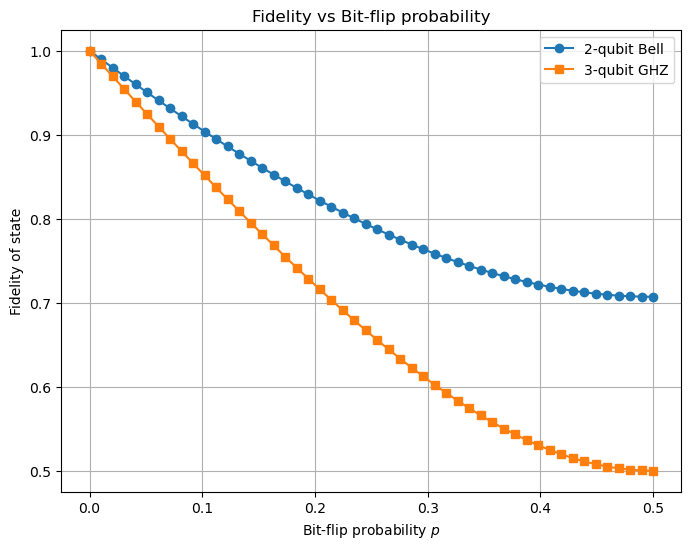

In [40]:
# Range of bit-flip probabilities
p_values = np.linspace(0, 0.5, 50)

# Prepare arrays to store fidelities
fidelity_2q = []
fidelity_3q = []

# Loop over p values
for p in p_values:
    #2-qubit Bell state 
    initial_state = np.kron(qec.operators.ket0(), qec.operators.ket0())
    H1 = np.kron(qec.operators.H, qec.operators.I)
    state_after_H = H1 @ initial_state
    CNOT12 = qec.operators.controlled_gate(qec.operators.X, 0, 1, 2)
    psi_bell = CNOT12 @ state_after_H
    rho_bell = qec.operators.dm(psi_bell)
    
    kraus_2q = qec.operators.bit_flip_kraus_nqubits(p=p, n=2)
    rho_noisy_2q = qec.operators.apply_kraus(rho_bell, kraus_2q)
    
    F2 = np.sqrt(np.abs(np.vdot(psi_bell, rho_noisy_2q @ psi_bell)))
    fidelity_2q.append(F2)
    
    #3-qubit GHZ state
    psi_ghz = (np.kron(np.kron(qec.operators.ket0(), qec.operators.ket0()), qec.operators.ket0()) +
               np.kron(np.kron(qec.operators.ket1(), qec.operators.ket1()), qec.operators.ket1())) / np.sqrt(2)
    rho_ghz = qec.operators.dm(psi_ghz)
    
    kraus_3q = qec.operators.bit_flip_kraus_nqubits(p=p, n=3)
    rho_noisy_3q = qec.operators.apply_kraus(rho_ghz, kraus_3q)
    
    F3 = np.sqrt(np.abs(np.vdot(psi_ghz, rho_noisy_3q @ psi_ghz)))
    fidelity_3q.append(F3)

# Convert to numpy arrays
fidelity_2q = np.array(fidelity_2q)
fidelity_3q = np.array(fidelity_3q)


plt.figure(figsize=(8,6))
plt.plot(p_values, fidelity_2q, 'o-', label='2-qubit Bell')
plt.plot(p_values, fidelity_3q, 's-', label='3-qubit GHZ')
plt.xlabel("Bit-flip probability $p$")
plt.ylabel("Fidelity of state")
plt.title("Fidelity vs Bit-flip probability")
plt.grid(True)
plt.legend()
plt.show()

### Conclusion

The fidelity decreases as the bit-flip probability \(p\) increases, showing that noise degrades the prepared entangled state. The 3-qubit GHZ state loses fidelity faster than the 2-qubit Bell state because the probability of errors increases with the number of qubits. This demonstrates that larger entangled systems are more sensitive to noise.

When \(p = 0\), no bit-flip noise is applied and the fidelity is equal to 1. As the probability increases, noise introduces errors and the fidelity decreases. Around \(p = 0.5\) the state becomes highly mixed and the fidelity is lowest. For \(p = 1\), all qubits flip, but due to the symmetry of Bell and GHZ states the structure of the entangled state is preserved, leading to a higher fidelity again.

### Problem 3: Simulating a quantum error correction protocol

We now come to the part of the assignment where we will implement an error correction code to the noisy state preparation. We assume perfect circuit elements and only apply error channels at certain points.

We will focus on the 3-qubit bit flip code.

#### (a) Error correction protocol

Simulate each step of the error correction protocol. In each step you should test that your code produces the expected outcome.

1) Encoding: Write a function that takes as an input a general single-qubit state. The output is the encoded state for the three qubit code space of the bit flip code and calculated by simulating the encoding circuit (the second and third qubit are initialized in state $|0\rangle$). You may assume that the input state is pure. 

2) Error: Write a function that applies the bit flip channel to all (three) qubits of the register.

3) Syndrome measurement: In order to perform the syndrome measurement you have to build the projectors $(P_0,P_1,P_2,P_3)$ onto the subspaces corresponding to different error syndromes, i.e., possible outcomes of the syndrome measurement. With these you can simulate the syndrome measurement using the function `doMeasurement()` provided below. Make sure you understand what it does.

4) Recovery: Apply the recovery operation corresponding to the detected syndrome, i.e., apply the channel $\mathcal{E}(\rho)=M_i \rho M_i^\dagger$ with $M_i = 1,X_1,X_2,X_3$, respectively, for the bit flip channel.

Optional: Do all of this for the phase flip code also!

The error correction protocol is not always successful, namely in the case where two or three errors occur. How does this manifest in the simulated protocol? Try different input states and different noise strengths.


1) Encoding: Write a function that takes as an input a general single-qubit state. The output is the encoded state for the three qubit code space of the bit flip code and calculated by simulating the encoding circuit (the second and third qubit are initialized in state $|0\rangle$). You may assume that the input state is pure. 

In [41]:
psi = np.array([0.5, 0.5])  
encoded_psi = qec.operators.encode_3_qubit_bit_flip_code(psi)

print("Encoded 3-qubit state:\n", encoded_psi)

Encoded 3-qubit state:
 [0.5+0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0.5+0.j]


2. Error: Write a function that applies the bit flip channel to all (three) qubits of the register.

In [42]:
psi = np.array([0.5, 0.5])
psi = np.kron(psi, np.kron(qec.operators.ket0(), qec.operators.ket0()))
print(" psi :\n", psi)

 psi :
 [0.5+0.j 0. +0.j 0. +0.j 0. +0.j 0.5+0.j 0. +0.j 0. +0.j 0. +0.j]


In [43]:
psi = np.array([0.5, 0.5])
encoded = qec.operators.encode_3_qubit_bit_flip_code(psi)
print("Encoded state:\n", encoded)
print()
psi_after_noise = qec.operators.bit_flip_channel_3qubits(encoded, psi)
print("State after noise:\n", psi_after_noise)

error = np.kron(qec.operators.I, np.kron(qec.operators.I, qec.operators.I))
errored_state = error @ encoded
print("Errored state:\n", errored_state)
print()
syndrome = qec.operators.syndrome_measurement_bit_flip(errored_state)
print("Syndrome (S1, S2):\n", syndrome)
print()
corrected_state = qec.operators.correct_bit_flip(errored_state)
print("Corrected state:\n", corrected_state)

Encoded state:
 [0.5+0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0.5+0.j]

State after noise:
 [0.35355339+0.j 0.35355339+0.j 0.35355339+0.j 0.35355339+0.j
 0.35355339+0.j 0.35355339+0.j 0.35355339+0.j 0.35355339+0.j]
Errored state:
 [0.5+0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0.5+0.j]

Syndrome (S1, S2):
 (1, 1)

Corrected state:
 [0.5+0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0.5+0.j]


In [44]:
psi = np.array([0.5, 0.5])
encoded = qec.operators.encode_3_qubit_bit_flip_code(psi)
print("Encoded state:\n", encoded)
print()
psi_after_noise = qec.operators.bit_flip_channel_3qubits(encoded, p)
print("State after noise:\n", psi_after_noise)

error = np.kron(qec.operators.X, np.kron(qec.operators.I, qec.operators.I))
errored_state = error @ encoded
print("Errored state:\n", errored_state)
print()
syndrome = qec.operators.syndrome_measurement_bit_flip(errored_state)
print("Syndrome (S1, S2):\n", syndrome)
print()
corrected_state = qec.operators.correct_bit_flip(errored_state)
print("Corrected state:\n", corrected_state)

Encoded state:
 [0.5+0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0.5+0.j]

State after noise:
 [0.35355339+0.j 0.35355339+0.j 0.35355339+0.j 0.35355339+0.j
 0.35355339+0.j 0.35355339+0.j 0.35355339+0.j 0.35355339+0.j]
Errored state:
 [0. +0.j 0. +0.j 0. +0.j 0.5+0.j 0.5+0.j 0. +0.j 0. +0.j 0. +0.j]

Syndrome (S1, S2):
 (-1, 1)

Corrected state:
 [0.5+0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0.5+0.j]


In [45]:
psi = np.array([0.3, 0.7])
encoded = qec.operators.encode_3_qubit_bit_flip_code(psi)
print("Encoded state:\n", encoded)
error = np.kron(qec.operators.I, np.kron(qec.operators.X, qec.operators.I))  
errored_state = error @ encoded
print()
print("errored_state:\n", errored_state)

syndrome = qec.operators.syndrome_measurement_bit_flip(errored_state)
print("Syndrome (S1, S2):\n", syndrome)

corrected_state = qec.operators.correct_bit_flip(errored_state)
print("Corrected state:\n", corrected_state)

Encoded state:
 [0.3+0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0.7+0.j]

errored_state:
 [0. +0.j 0. +0.j 0.3+0.j 0. +0.j 0. +0.j 0.7+0.j 0. +0.j 0. +0.j]
Syndrome (S1, S2):
 (-1, -1)
Corrected state:
 [0.3+0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0.7+0.j]


In [46]:
psi = np.array([0.3, 0.7])
encoded = qec.operators.encode_3_qubit_bit_flip_code(psi)
print("Encoded state:\n", encoded)
error = np.kron(qec.operators.I, np.kron(qec.operators.I, qec.operators.X))  
errored_state = error @ encoded
print()
print("errored_state:\n", errored_state)

syndrome = qec.operators.syndrome_measurement_bit_flip(errored_state)
print("Syndrome (S1, S2):\n", syndrome)

corrected_state = qec.operators.correct_bit_flip(errored_state)
print("Corrected state:\n", corrected_state)

Encoded state:
 [0.3+0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0.7+0.j]

errored_state:
 [0. +0.j 0.3+0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0.7+0.j 0. +0.j]
Syndrome (S1, S2):
 (1, -1)
Corrected state:
 [0.3+0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0.7+0.j]


3) Syndrome measurement: In order to perform the syndrome measurement you have to build the projectors $(P_0,P_1,P_2,P_3)$ onto the subspaces corresponding to different error syndromes, i.e., possible outcomes of the syndrome measurement. With these you can simulate the syndrome measurement using the function `doMeasurement()` provided below. Make sure you understand what it does.

In [47]:
psi = np.array([0.5, 0.5])
encoded_psi = qec.operators.encode_3_qubit_bit_flip_code(psi)
error = np.kron(qec.operators.I, np.kron(qec.operators.I, qec.operators.X))  
errored_state = error @ encoded_psi
print("Encoded 3-qubit state:\n", errored_state)
rho = np.outer(errored_state, errored_state.conj())
basis = qec.operators.projectors(2**3)
P0 = basis[0] + basis[7]   # no error
P1 = basis[4] + basis[3]   # error on qubit 1
P2 = basis[2] + basis[5]   # error on qubit 2
P3 = basis[1] + basis[6]   # error on qubit 3

syndrome_projectors = [P0, P1, P2, P3]

# Step 6: perform measurement
outcome, collapsed_state, probs = qec.operators.doMeasurement(rho, syndrome_projectors)
print("P0:\n", P0)
print("P1:\n", P1)
print("P2:\n", P2)
print("P3:\n", P3)
syndrome = qec.operators.syndrome_measurement_bit_flip(errored_state)
print("Syndrome (S1, S2):\n", syndrome)

print("Syndrome outcome index:", outcome)
print("Collapsed density matrix:\n", collapsed_state)
print("Measurement probabilities:", probs)

Encoded 3-qubit state:
 [0. +0.j 0.5+0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0.5+0.j 0. +0.j]
P0:
 [[1.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 1.+0.j]]
P1:
 [[0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 1.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 1.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.

In [48]:
psi = np.array([0.5, 0.5])
encoded_psi = qec.operators.encode_3_qubit_bit_flip_code(psi)
error = np.kron(qec.operators.I, np.kron(qec.operators.I, qec.operators.I))  
errored_state = error @ encoded_psi
print("Encoded 3-qubit state:\n", errored_state)
rho = np.outer(errored_state, errored_state.conj())

basis = qec.operators.projectors(2**3)

P0 = basis[0] + basis[7]   # no error
P1 = basis[4] + basis[3]   # error on qubit 1
P2 = basis[2] + basis[5]   # error on qubit 2
P3 = basis[1] + basis[6]   # error on qubit 3

syndromes = [P0, P1, P2, P3]

# Step 6: perform measurement
outcome, post, probs = qec.operators.doMeasurement(rho, syndromes)
print("P0:\n", P0)
print("P1:\n", P1)
print("P2:\n", P2)
print("P3:\n", P3)
syndrome = qec.operators.syndrome_measurement_bit_flip(errored_state)
print("Syndrome (S1, S2):\n", syndrome)

print("Syndrome index:\n", outcome)
print("state after:\n", post)
print("Measurement probabilities:\n", probs)

Encoded 3-qubit state:
 [0.5+0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0.5+0.j]
P0:
 [[1.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 1.+0.j]]
P1:
 [[0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 1.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 1.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.

4) Recovery: Apply the recovery operation corresponding to the detected syndrome, i.e., apply the channel $\mathcal{E}(\rho)=M_i \rho M_i^\dagger$ with $M_i = 1,X_1,X_2,X_3$, respectively, for the bit flip channel.

Optional: Do all of this for the phase flip code also!

The error correction protocol is not always successful, namely in the case where two or three errors occur. How does this manifest in the simulated protocol? Try different input states and different noise strengths.

In [49]:
psi = np.array([0.5,0.5])               
encoded_psi = qec.operators.encode_3_qubit_bit_flip_code(psi)
errored_psi = qec.operators.X2 @ encoded_psi
corrected_psi = qec.operators.correct_bit_flip(errored_psi)
print("encoded_psi:\n", encoded_psi)
print("errored_psi:\n", errored_psi)
corrected_psi = qec.operators.correct_bit_flip(errored_psi)
print("corrected_psi:\n", corrected_psi)
fidelity_corrected = np.abs(np.vdot(encoded_psi, corrected_psi))**2
print("Fidelity after recovery:\n", fidelity_corrected)

encoded_psi:
 [0.5+0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0.5+0.j]
errored_psi:
 [0. +0.j 0. +0.j 0.5+0.j 0. +0.j 0. +0.j 0.5+0.j 0. +0.j 0. +0.j]
corrected_psi:
 [0.5+0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0.5+0.j]
Fidelity after recovery:
 0.25


In [50]:
psi = np.array([0.7,0.3])               
encoded_psi = qec.operators.encode_3_qubit_bit_flip_code(psi)
print("encoded_psi:\n", encoded_psi)
errored_psi = qec.operators.X3 @ encoded_psi
print("errored_psi:\n", errored_psi)
corrected_psi = qec.operators.correct_bit_flip(errored_psi)
print("corrected_psi:\n", corrected_psi)

# Fidelity with encoded state
fidelity_corrected = np.abs(np.vdot(encoded_psi, corrected_psi))**2
print("Fidelity after recovery:\n", fidelity_corrected)

encoded_psi:
 [0.7+0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0.3+0.j]
errored_psi:
 [0. +0.j 0.7+0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0.3+0.j 0. +0.j]
corrected_psi:
 [0.7+0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0.3+0.j]
Fidelity after recovery:
 0.3364


In [51]:
psi = np.array([0.4,0.6])               
encoded_psi = qec.operators.encode_3_qubit_bit_flip_code(psi)
print("encoded_psi:\n", encoded_psi)
errored_psi = qec.operators.I8 @ encoded_psi
print("errored_psi:\n", errored_psi)
corrected_psi = qec.operators.correct_bit_flip(errored_psi)
print("corrected_psi:\n", corrected_psi)
fidelity_corrected = np.abs(np.vdot(encoded_psi, corrected_psi))**2
print("Fidelity after recovery:\n", fidelity_corrected)

encoded_psi:
 [0.4+0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0.6+0.j]
errored_psi:
 [0.4+0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0.6+0.j]
corrected_psi:
 [0.4+0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0. +0.j 0.6+0.j]
Fidelity after recovery:
 0.27040000000000003


 Do all of this for the phase flip code also!

The error correction protocol is not always successful, namely in the case where two or three errors occur. How does this manifest in the simulated protocol? Try different input states and different noise strengths.

In [52]:
psi = qec.operators.ket_plus()
encoded_psi = qec.operators.encode_3_qubit_phase_flip_code(psi)
print("Encoded 3-qubit state:\n", encoded_psi)

Encoded 3-qubit state:
 [0.5+0.j 0. +0.j 0. +0.j 0.5+0.j 0. +0.j 0.5+0.j 0.5+0.j 0. +0.j]


In [53]:
psi = qec.operators.ket_plus()            
encoded_psi = qec.operators.encode_3_qubit_phase_flip_code(psi)
print("encoded_psi:\n", encoded_psi)
errored_psi = qec.operators.Z1 @ encoded_psi
print("errored_psi:\n", errored_psi)
corrected_psi = qec.operators.correct_bit_flip(errored_psi)
print("corrected_psi:\n", corrected_psi)

encoded_psi:
 [0.5+0.j 0. +0.j 0. +0.j 0.5+0.j 0. +0.j 0.5+0.j 0.5+0.j 0. +0.j]
errored_psi:
 [ 0.5+0.j  0. +0.j  0. +0.j  0.5+0.j  0. +0.j -0.5+0.j -0.5+0.j  0. +0.j]
corrected_psi:
 [ 0. +0.j  0.5+0.j  0.5+0.j  0. +0.j -0.5+0.j  0. +0.j  0. +0.j -0.5+0.j]


In [54]:
psi = qec.operators.ket_minus()            
encoded_psi = qec.operators.encode_3_qubit_phase_flip_code(psi)
print("encoded_psi:\n", encoded_psi)
errored_psi =  qec.operators.Z3@encoded_psi
print("errored_psi:\n", errored_psi)
corrected_psi = qec.operators.correct_bit_flip(errored_psi)
print("corrected_psi:\n", corrected_psi)

encoded_psi:
 [0. +0.j 0.5+0.j 0.5+0.j 0. +0.j 0.5+0.j 0. +0.j 0. +0.j 0.5+0.j]
errored_psi:
 [ 0. +0.j -0.5+0.j  0.5+0.j  0. +0.j  0.5+0.j  0. +0.j  0. +0.j -0.5+0.j]
corrected_psi:
 [ 0.5+0.j  0. +0.j  0. +0.j -0.5+0.j  0. +0.j -0.5+0.j  0.5+0.j  0. +0.j]


In [55]:
psi = qec.operators.ket_plus()   
encoded_psi = qec.operators.encode_3_qubit_phase_flip_code(psi)
errored_psi = qec.operators.Z2 @ encoded_psi   
corrected_psi = qec.operators.correct_phase_flip(errored_psi)
print("errored_psi:\n", errored_psi)
print("corrected_psi:\n", corrected_psi)

errored_psi:
 [ 0.5+0.j  0. +0.j  0. +0.j -0.5+0.j  0. +0.j  0.5+0.j -0.5+0.j  0. +0.j]
corrected_psi:
 [0.5+0.j 0. +0.j 0. +0.j 0.5+0.j 0. +0.j 0.5+0.j 0.5+0.j 0. +0.j]


#### (b) Analyzing the performance of the error correction protocol

Use the state obtained by applying the error channel to study the average performance (success rate) of the error correction propotcol and compare it to the case where no error correction is applied: Write a loop that perform the error correction protocol (syndrome measurement and recovery) multiple times. Each time the simulation of the measurement will provide random outcomes.

Calculate the average fidelity over many runs, i.e., the fidelity between the errror corrected state and the encoded state before the error channel.

Compare this to the non-corrected fidelity, i.e., the fidelity between the initial single qubit input state and the state after applying the error channel to this qubit.

How much does the error correction protocol improve the fidelity? How does this depend on the error probability $p$? It will also depend on the input state! Recall that there are states that are not affected at all by the bit flip channel. Can the error corrected fidelity be worse than the uncorrected one?

In [57]:
psi = qec.operators.ket_plus()               
encoded_state = qec.operators.encode_3_qubit_bit_flip_code(psi)
p = 0.2                        
num_runs = 1000
f_corr = []
f_uncorr = []


# Monte Carlo simulation
for _ in range(num_runs):
    errored = qec.operators.bit_flip_channel_3qubits(encoded_state, p)
    corrected = qec.operators.correct_bit_flip(errored)
    corrected_sv = Statevector(corrected / np.linalg.norm(corrected))
    encoded_sv = Statevector(encoded_state / np.linalg.norm(encoded_state))
    F_corr = state_fidelity(corrected_sv, encoded_sv)
    f_corr.append(F_corr)
    single_error = qec.operators.E1_rho(psi, p)          
    single_dm = DensityMatrix(single_error)
    psi_dm = DensityMatrix(np.outer(psi, psi.conj()))
    F_uncorr = state_fidelity(single_dm, psi_dm)
    f_uncorr.append(F_uncorr)

avg_corr = np.mean(f_corr)
avg_uncorr = np.mean(f_uncorr)
print("Average corrected fidelity:\n", avg_corr)
print("Average uncorrected fidelity:\n", avg_uncorr)
print("Improvement=", avg_corr - avg_uncorr)

Average corrected fidelity:
 0.42857142857142877
Average uncorrected fidelity:
 1.0000000000000002
Improvement= -0.5714285714285714


In [58]:
psi = qec.operators.ket_plus()               
encoded_state = qec.operators.encode_3_qubit_bit_flip_code(psi)
p = 0.9                       
num_runs = 1000
f_corr = []
f_uncorr = []


# Monte Carlo simulation
for _ in range(num_runs):
    errored = qec.operators.bit_flip_channel_3qubits(encoded_state, p)
    corrected = qec.operators.correct_bit_flip(errored)
    corrected_sv = Statevector(corrected / np.linalg.norm(corrected))
    encoded_sv = Statevector(encoded_state / np.linalg.norm(encoded_state))
    F_corr = state_fidelity(corrected_sv, encoded_sv)
    f_corr.append(F_corr)
    single_error = qec.operators.E1_rho(psi, p)          
    single_dm = DensityMatrix(single_error)
    psi_dm = DensityMatrix(np.outer(psi, psi.conj()))
    F_uncorr = state_fidelity(single_dm, psi_dm)
    f_uncorr.append(F_uncorr)

avg_corr = np.mean(f_corr)
avg_uncorr = np.mean(f_uncorr)
print("Average corrected fidelity:\n", avg_corr)
print("Average uncorrected fidelity:\n", avg_uncorr)
print("Improvement=", avg_corr - avg_uncorr)

Average corrected fidelity:
 0.6447368421052636
Average uncorrected fidelity:
 1.0000000000000004
Improvement= -0.35526315789473684


In [59]:
psi = qec.operators.ket0()               
encoded_state = qec.operators.encode_3_qubit_bit_flip_code(psi)
p = 0.2                     
num_runs = 1000
f_corr = []
f_uncorr = []


# Monte Carlo simulation
for _ in range(num_runs):
    errored = qec.operators.bit_flip_channel_3qubits(encoded_state, p)
    corrected = qec.operators.correct_bit_flip(errored)
    corrected_sv = Statevector(corrected / np.linalg.norm(corrected))
    encoded_sv = Statevector(encoded_state / np.linalg.norm(encoded_state))
    F_corr = state_fidelity(corrected_sv, encoded_sv)
    f_corr.append(F_corr)
    single_error = qec.operators.E1_rho(psi, p)          
    single_dm = DensityMatrix(single_error)
    psi_dm = DensityMatrix(np.outer(psi, psi.conj()))
    F_uncorr = state_fidelity(single_dm, psi_dm)
    f_uncorr.append(F_uncorr)

avg_corr = np.mean(f_corr)
avg_uncorr = np.mean(f_uncorr)
print("Average corrected fidelity:\n", avg_corr)
print("Average uncorrected fidelity:\n", avg_uncorr)
print("Improvement=", avg_corr - avg_uncorr)

Average corrected fidelity:
 0.5120000000000002
Average uncorrected fidelity:
 0.8000000000000002
Improvement= -0.2879999999999999


In [60]:
psi = qec.operators.ket0()               
encoded_state = qec.operators.encode_3_qubit_bit_flip_code(psi)
p = 0.9                      
num_runs = 1000
f_corr = []
f_uncorr = []


# Monte Carlo simulation
for _ in range(num_runs):
    errored = qec.operators.bit_flip_channel_3qubits(encoded_state, p)
    corrected = qec.operators.correct_bit_flip(errored)
    corrected_sv = Statevector(corrected / np.linalg.norm(corrected))
    encoded_sv = Statevector(encoded_state / np.linalg.norm(encoded_state))
    F_corr = state_fidelity(corrected_sv, encoded_sv)
    f_corr.append(F_corr)
    single_error = qec.operators.E1_rho(psi, p)          
    single_dm = DensityMatrix(single_error)
    psi_dm = DensityMatrix(np.outer(psi, psi.conj()))
    F_uncorr = state_fidelity(single_dm, psi_dm)
    f_uncorr.append(F_uncorr)

avg_corr = np.mean(f_corr)
avg_uncorr = np.mean(f_uncorr)
print("Average corrected fidelity:\n", avg_corr)
print("Average uncorrected fidelity:\n", avg_uncorr)
print("Improvement=", avg_corr - avg_uncorr)

Average corrected fidelity:
 0.0009999999999999994
Average uncorrected fidelity:
 0.09999999999999992
Improvement= -0.09899999999999992


In [61]:
psi = qec.operators.ket1()               
encoded_state = qec.operators.encode_3_qubit_bit_flip_code(psi)
p = 0.2                      
num_runs = 1000
f_corr = []
f_uncorr = []


# Monte Carlo simulation
for _ in range(num_runs):
    errored = qec.operators.bit_flip_channel_3qubits(encoded_state, p)
    corrected = qec.operators.correct_bit_flip(errored)
    corrected_sv = Statevector(corrected / np.linalg.norm(corrected))
    encoded_sv = Statevector(encoded_state / np.linalg.norm(encoded_state))
    F_corr = state_fidelity(corrected_sv, encoded_sv)
    f_corr.append(F_corr)
    single_error = qec.operators.E1_rho(psi, p)          
    single_dm = DensityMatrix(single_error)
    psi_dm = DensityMatrix(np.outer(psi, psi.conj()))
    F_uncorr = state_fidelity(single_dm, psi_dm)
    f_uncorr.append(F_uncorr)

avg_corr = np.mean(f_corr)
avg_uncorr = np.mean(f_uncorr)
print("Average corrected fidelity:\n", avg_corr)
print("Average uncorrected fidelity:\n", avg_uncorr)
print("Improvement=", avg_corr - avg_uncorr)

Average corrected fidelity:
 0.5120000000000002
Average uncorrected fidelity:
 0.8000000000000002
Improvement= -0.2879999999999999


In [62]:
psi = qec.operators.ket1()               
encoded_state = qec.operators.encode_3_qubit_bit_flip_code(psi)
p = 0.9                        
num_runs = 1000
f_corr = []
f_uncorr = []


# Monte Carlo simulation
for _ in range(num_runs):
    errored = qec.operators.bit_flip_channel_3qubits(encoded_state, p)
    corrected = qec.operators.correct_bit_flip(errored)
    corrected_sv = Statevector(corrected / np.linalg.norm(corrected))
    encoded_sv = Statevector(encoded_state / np.linalg.norm(encoded_state))
    F_corr = state_fidelity(corrected_sv, encoded_sv)
    f_corr.append(F_corr)
    single_error = qec.operators.E1_rho(psi, p)          
    single_dm = DensityMatrix(single_error)
    psi_dm = DensityMatrix(np.outer(psi, psi.conj()))
    F_uncorr = state_fidelity(single_dm, psi_dm)
    f_uncorr.append(F_uncorr)

avg_corr = np.mean(f_corr)
avg_uncorr = np.mean(f_uncorr)
print("Average corrected fidelity:\n", avg_corr)
print("Average uncorrected fidelity:\n", avg_uncorr)
print("Improvement=", avg_corr - avg_uncorr)

Average corrected fidelity:
 0.0009999999999999994
Average uncorrected fidelity:
 0.09999999999999992
Improvement= -0.09899999999999992


In [63]:
psi = qec.operators.ket_minus()               
encoded_state = qec.operators.encode_3_qubit_bit_flip_code(psi)
p = 0.2                        
num_runs = 1000
f_corr = []
f_uncorr = []


# Monte Carlo simulation
for _ in range(num_runs):
    errored = qec.operators.bit_flip_channel_3qubits(encoded_state, p)
    corrected = qec.operators.correct_bit_flip(errored)
    corrected_sv = Statevector(corrected / np.linalg.norm(corrected))
    encoded_sv = Statevector(encoded_state / np.linalg.norm(encoded_state))
    F_corr = state_fidelity(corrected_sv, encoded_sv)
    f_corr.append(F_corr)
    single_error = qec.operators.E1_rho(psi, p)          
    single_dm = DensityMatrix(single_error)
    psi_dm = DensityMatrix(np.outer(psi, psi.conj()))
    F_uncorr = state_fidelity(single_dm, psi_dm)
    f_uncorr.append(F_uncorr)

avg_corr = np.mean(f_corr)
avg_uncorr = np.mean(f_uncorr)
print("Average corrected fidelity:\n", avg_corr)
print("Average uncorrected fidelity:\n", avg_uncorr)
print("Improvement=", avg_corr - avg_uncorr)

Average corrected fidelity:
 0.8032786885245907
Average uncorrected fidelity:
 1.0000000000000002
Improvement= -0.1967213114754095


In [64]:
psi = qec.operators.ket_minus()               
encoded_state = qec.operators.encode_3_qubit_bit_flip_code(psi)
p = 0.9                        
num_runs = 1000
f_corr = []
f_uncorr = []


# Monte Carlo simulation
for _ in range(num_runs):
    errored = qec.operators.bit_flip_channel_3qubits(encoded_state, p)
    corrected = qec.operators.correct_bit_flip(errored)
    corrected_sv = Statevector(corrected / np.linalg.norm(corrected))
    encoded_sv = Statevector(encoded_state / np.linalg.norm(encoded_state))
    F_corr = state_fidelity(corrected_sv, encoded_sv)
    f_corr.append(F_corr)
    single_error = qec.operators.E1_rho(psi, p)          
    single_dm = DensityMatrix(single_error)
    psi_dm = DensityMatrix(np.outer(psi, psi.conj()))
    F_uncorr = state_fidelity(single_dm, psi_dm)
    f_uncorr.append(F_uncorr)

avg_corr = np.mean(f_corr)
avg_uncorr = np.mean(f_uncorr)
print("Average corrected fidelity:\n", avg_corr)
print("Average uncorrected fidelity:\n", avg_uncorr)
print("Improvement=", avg_corr - avg_uncorr)

Average corrected fidelity:
 0.8622448979591844
Average uncorrected fidelity:
 1.0000000000000004
Improvement= -0.1377551020408161


Summary
- The 3-qubit bit-flip code was tested with p = 0.2 and 0.9 for different input states.
- Corrected fidelity overlap with the encoded state after error + correction.
- Uncorrected fidelity overlap with the original input state after noise only.
- Improvement corrected fidelity − uncorrected fidelity.

Observations
1. For `|0⟩` and `|1⟩`, correction reduces fidelity because multiple flips can occur and the code only corrects one error.
2. For `|+⟩` and `|−⟩`, correction can also decrease fidelity, especially for `|+⟩`, because single-qubit X flips leave it unchanged.
3. At this error rate, the 3-qubit code does not improve fidelity for any of these states.
4. Error correction is most effective at low error probabilities and depends on the input state.
